# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [1]:
# 현재 Jupyter 커널에 필요한 패키지가 없을 때만 설치합니다.
import importlib.util
import subprocess
import sys

required = {
    'numpy': 'numpy', 'pandas': 'pandas', 'mat73': 'mat73',
    'scipy': 'scipy', 'matplotlib': 'matplotlib', 'h5py': 'h5py'
}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('설치 완료:', ', '.join(missing))
else:
    print('필요한 패키지가 모두 설치되어 있습니다.')


필요한 패키지가 모두 설치되어 있습니다.


In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# 현재 프로젝트의 데이터 경로 설정
from pathlib import Path

DATA_DIR = Path.cwd() / 'data'
if not DATA_DIR.exists():
    raise FileNotFoundError(f'데이터 폴더를 찾을 수 없습니다: {DATA_DIR}')

files = sorted(path for path in DATA_DIR.iterdir() if path.is_file())
print(f'데이터 경로 : {DATA_DIR}')
print('파일 목록 :')
for path in files:
    size_gb = path.stat().st_size / (1024**3)
    print(f'   {path.name}  ({size_gb:.1f} GB)')


데이터 경로 : /Users/gaeun/Downloads/workspace/16. 데이터 분석 mini-project/mini-project/data
파일 목록 :
   Batch1  (2.8 GB)
   Batch2  (1.9 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [4]:
# Batch 1 로드 (현재 프로젝트의 MATLAB v7.3/HDF5 파일)
batch1_path = DATA_DIR / 'Batch1'

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    if not path.exists():
        raise FileNotFoundError(f'Batch1 파일을 찾을 수 없습니다: {path}')
    try:
        data = mat73.loadmat(str(path))
        print('로드 완료 (MATLAB v7.3 / HDF5 형식)')
    except Exception as exc:
        print(f'mat73 로드 실패({type(exc).__name__}), scipy로 다시 시도합니다.')
        data = sio.loadmat(str(path), simplify_cells=True)
        print('로드 완료 (MATLAB v7.2 이하 형식)')
    return data

print('로딩 중... (2.8GB 파일이므로 시간이 걸릴 수 있습니다)')
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f'\n최상위 키 : {list(mat.keys())}')


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (2.8GB 파일이므로 시간이 걸릴 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [5]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [7]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [8]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [9]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [10]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [11]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


### 데이터 품질 점검

각 변수의 자료형과 결측치·무한값을 확인합니다.


In [12]:
# 데이터 타입, 무한값, 결측치 점검
numeric_cols = ['cycle_life', 'cycle', 'QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']
quality = pd.DataFrame({
    'dtype': df[numeric_cols].dtypes.astype(str),
    'missing_count': df[numeric_cols].isna().sum(),
    'missing_rate_pct': df[numeric_cols].isna().mean().mul(100),
    'infinite_count': [np.isinf(pd.to_numeric(df[c], errors='coerce')).sum() for c in numeric_cols],
})
quality.round(3)


,dtype,missing_count,missing_rate_pct,infinite_count
cycle_life,int64,0,0.0,0
cycle,int64,0,0.0,0
QD,float64,0,0.0,0
QC,float64,0,0.0,0
IR,float64,0,0.0,0
Tmax,float64,0,0.0,0
Tavg,float64,0,0.0,0
Tmin,float64,0,0.0,0
chargetime,float64,0,0.0,0


[check]
- `dtype`은 각 분석 변수가 수치형으로 읽혔는지 확인하는 항목이다. 수치형이어야 평균, 상관계수, 그래프 계산이 의도대로 동작한다.
- `missing_count`와 `missing_rate_pct`가 0보다 크면 해당 변수의 일부 사이클이 비어 있다는 뜻이다. 삭제하거나 보간하기 전에 특정 셀이나 구간에 몰려 있는지 먼저 확인해야 한다.
- `infinite_count`는 유한한 수치가 아닌 값의 개수다. 하나라도 있으면 평균과 상관계수 계산 전에 `NaN`으로 바꾸거나 원인을 확인해야 한다.
- 이 표는 결측치가 있다는 이유만으로 행을 바로 제거하기 위한 것이 아니다. 어떤 변수와 셀에서 발생했는지 확인한 뒤 처리 기준을 정하는 데 사용한다.


In [13]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

### 주요 측정값 분포

극단값 때문에 중심 분포가 가려지지 않도록 각 변수의 1~99 분위 범위를 표시합니다.


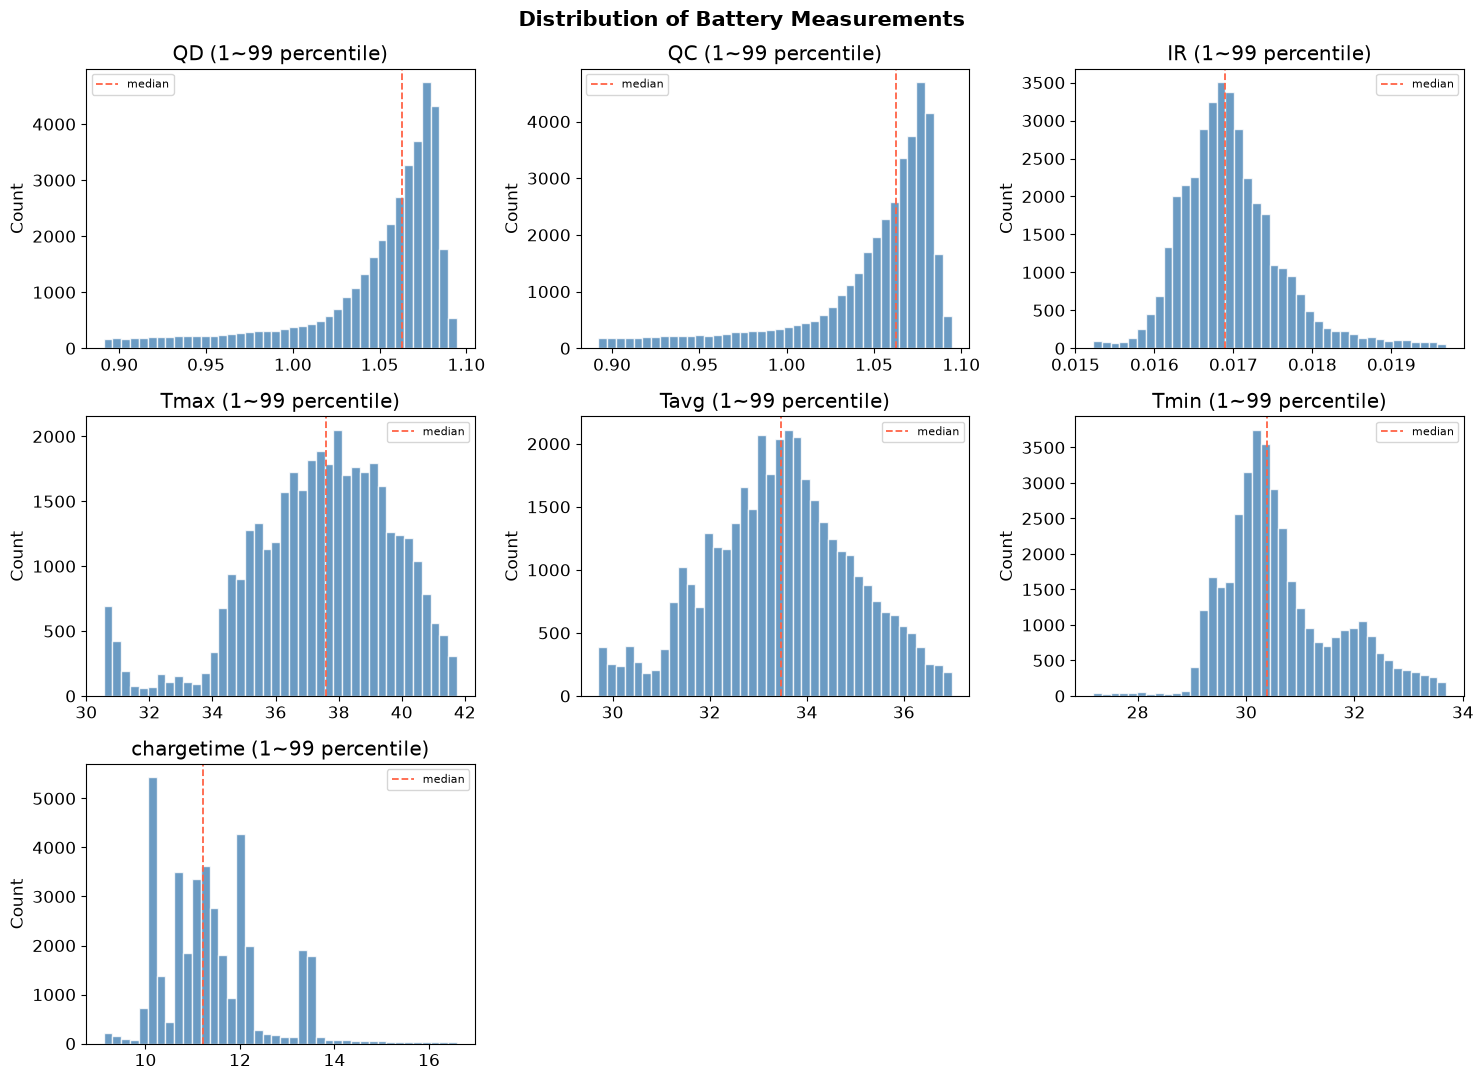

In [14]:
# 주요 측정값 분포: 극단값의 영향을 줄이기 위해 1~99 분위 범위로 표시
plot_cols = ['QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    values = pd.to_numeric(df[col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    low, high = values.quantile([0.01, 0.99])
    shown = values[values.between(low, high)]
    ax.hist(shown, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(shown.median(), color='tomato', linestyle='--', linewidth=1.3, label='median')
    ax.set_title(f'{col} (1~99 percentile)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for ax in axes[len(plot_cols):]:
    ax.axis('off')

plt.suptitle('Distribution of Battery Measurements', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


[plot]
- 각 그래프는 전체 값 중 1~99 분위 구간을 보여준다. 표시 범위 밖의 값은 그래프에서만 제외했으며 원본 `df`에서는 삭제하지 않았다.
- 붉은 점선은 표시된 값의 중앙값이다. 막대가 한쪽으로 길게 늘어나면 평균보다 중앙값이 대표값으로 더 적절할 수 있다.
- `QD`와 `QC`는 방전·충전 용량, `IR`은 내부 저항, `Tmax·Tavg·Tmin`은 온도, `chargetime`은 충전 시간을 나타낸다. 변수마다 단위와 범위가 다르므로 그래프 높이나 폭을 서로 직접 비교하면 안 된다.
- 분포가 여러 봉우리로 나뉘면 충전 정책이나 배터리 셀별 차이가 섞였을 가능성이 있다. 이 경우 `charging_policy` 또는 `cell_id`로 나눠 다시 확인할 수 있다.


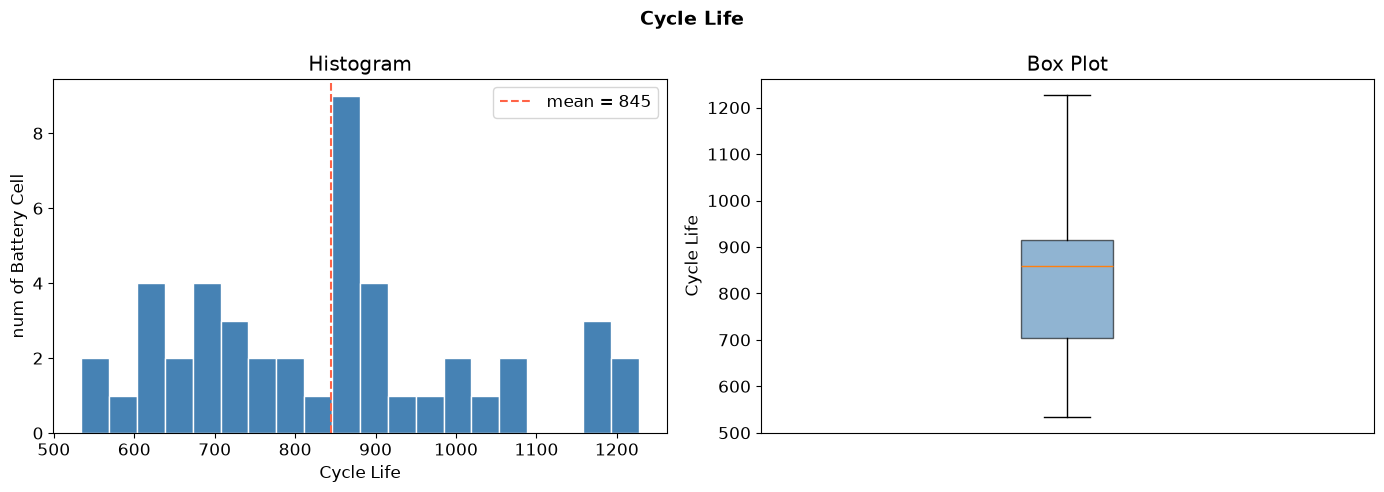

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [15]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

#### 수명 기준별 비율과 수명이 짧은 셀

요청한 기준에 해당하는 셀 수를 직접 확인하고, 수명이 가장 짧은 셀의 충전 정책을 함께 비교합니다.


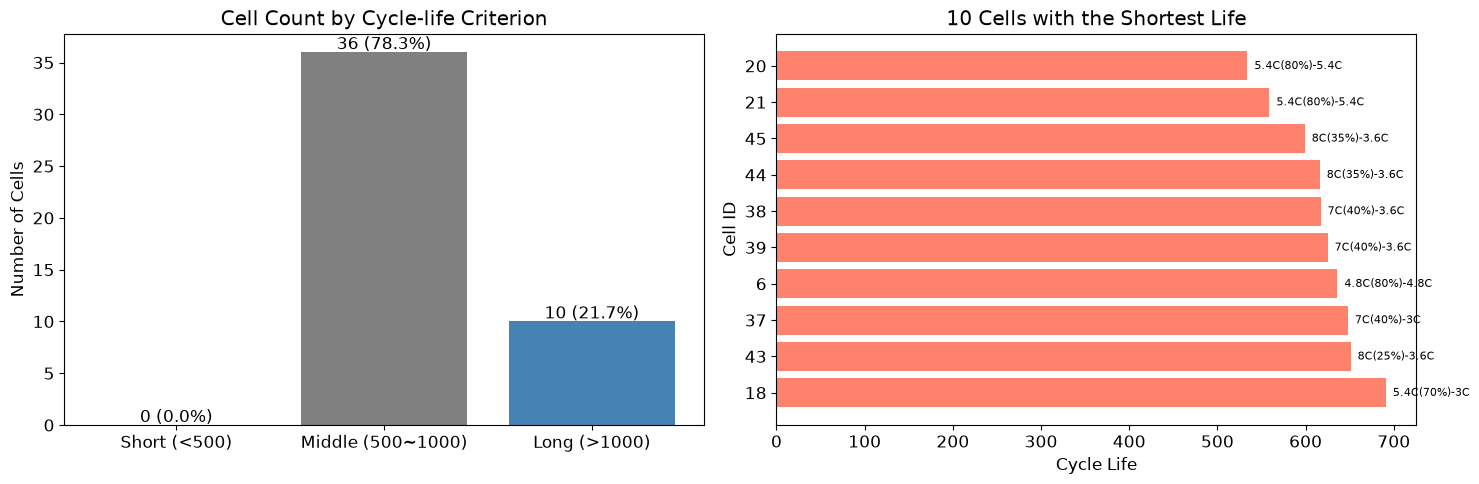

,count,ratio_pct
cycle_life,,
Short (<500),0,0.0
Middle (500~1000),36,78.3
Long (>1000),10,21.7


,cell_id,cycle_life,charging_policy
0,20,534,5.4C(80%)-5.4C
1,21,559,5.4C(80%)-5.4C
2,45,599,8C(35%)-3.6C
3,44,616,8C(35%)-3.6C
4,38,617,7C(40%)-3.6C
5,39,625,7C(40%)-3.6C
6,6,636,4.8C(80%)-4.8C
7,37,648,7C(40%)-3C
8,43,651,8C(25%)-3.6C
9,18,691,5.4C(70%)-3C


In [16]:
# 장수명(>1,000), 중간, 단수명(<500) 셀의 개수와 비율
life_groups = pd.cut(
    cycle_life_df['cycle_life'],
    bins=[-np.inf, 500, 1000, np.inf],
    labels=['Short (<500)', 'Middle (500~1000)', 'Long (>1000)'],
    right=False,
)
group_summary = life_groups.value_counts(sort=False).rename('count').to_frame()
group_summary['ratio_pct'] = group_summary['count'].div(len(cycle_life_df)).mul(100)

shortest = cycle_life_df.nsmallest(10, 'cycle_life').sort_values('cycle_life')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].bar(group_summary.index.astype(str), group_summary['count'],
                   color=['tomato', 'gray', 'steelblue'])
for bar, (_, row) in zip(bars, group_summary.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{int(row['count'])} ({row['ratio_pct']:.1f}%)", ha='center')
axes[0].set_ylabel('Number of Cells')
axes[0].set_title('Cell Count by Cycle-life Criterion')

axes[1].barh(shortest['cell_id'].astype(str), shortest['cycle_life'], color='tomato', alpha=0.8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Cycle Life')
axes[1].set_ylabel('Cell ID')
axes[1].set_title('10 Cells with the Shortest Life')
for y, (_, row) in enumerate(shortest.iterrows()):
    axes[1].text(row['cycle_life'] + 8, y, row['charging_policy'], va='center', fontsize=8)
plt.tight_layout()
plt.show()

display(group_summary.round(1))
display(shortest.reset_index(drop=True))


[plot]
- 왼쪽 그래프는 분석 기준에 실제로 몇 개의 셀이 포함되는지 보여준다. 특정 집단이 0개라면 그 기준으로 집단 비교나 모델 평가를 진행할 수 없다.
- 오른쪽 그래프에서는 하위 10개 셀의 충전 정책이 반복되는지 확인한다. 같은 정책이 반복돼도 다른 조건을 통제하지 않았으므로 원인으로 단정하지 않는다.
- Box plot에서 벗어나는 값과 단순히 수명이 짧은 값은 구분해야 한다. 통계적 이상치가 아니어도 하위 수명 셀은 별도의 분석 대상이 될 수 있다.


#### Batch1 내부 상대 수명군 비교

`<500`인 셀이 없어 절대 기준으로 장·단수명 비교를 할 수 없으므로, Batch1 내부 분포의 하위 25%와 상위 25%를 비교합니다. 이 그룹은 전체 데이터셋의 단수명·장수명 기준을 대체하지 않으며, Batch1 안에서 상대적으로 짧고 긴 셀을 비교하기 위한 기준입니다.


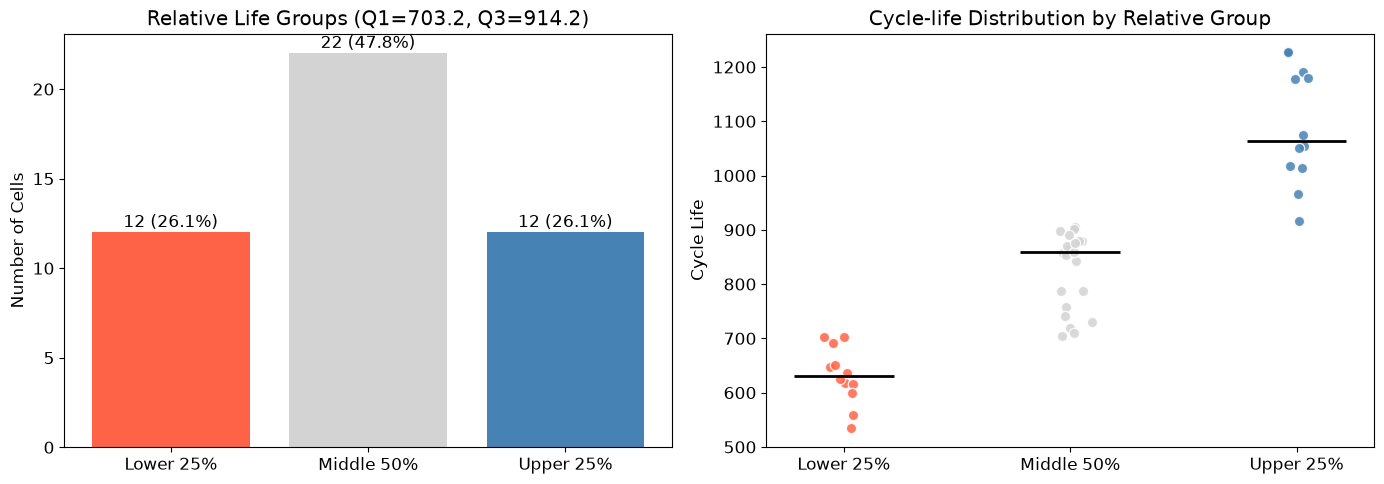

하위 25% 기준: cycle_life ≤ 703.2
상위 25% 기준: cycle_life ≥ 914.2


,count,ratio_pct
relative_group,,
Lower 25%,12,26.1
Middle 50%,22,47.8
Upper 25%,12,26.1


In [17]:
# Batch1 분위수 기준: 하위 25%, 중간 50%, 상위 25%
q1_life = cycle_life_df['cycle_life'].quantile(0.25)
q3_life = cycle_life_df['cycle_life'].quantile(0.75)

relative_life = cycle_life_df.copy()
relative_life['relative_group'] = np.select(
    [relative_life['cycle_life'] <= q1_life, relative_life['cycle_life'] >= q3_life],
    ['Lower 25%', 'Upper 25%'],
    default='Middle 50%',
)
group_order = ['Lower 25%', 'Middle 50%', 'Upper 25%']
relative_summary = (relative_life['relative_group'].value_counts()
                    .reindex(group_order).rename('count').to_frame())
relative_summary['ratio_pct'] = relative_summary['count'].div(len(relative_life)).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['tomato', 'lightgray', 'steelblue']
bars = axes[0].bar(group_order, relative_summary['count'], color=colors)
for bar, (_, row) in zip(bars, relative_summary.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{int(row['count'])} ({row['ratio_pct']:.1f}%)", ha='center')
axes[0].set_ylabel('Number of Cells')
axes[0].set_title(f'Relative Life Groups (Q1={q1_life:.1f}, Q3={q3_life:.1f})')

rng = np.random.default_rng(42)
for x, (group, color) in enumerate(zip(group_order, colors)):
    values = relative_life.loc[relative_life['relative_group'] == group, 'cycle_life']
    jitter = rng.normal(0, 0.045, len(values))
    axes[1].scatter(np.full(len(values), x) + jitter, values, color=color,
                    edgecolor='white', s=55, alpha=0.85)
    axes[1].hlines(values.median(), x - 0.22, x + 0.22, color='black', linewidth=2)
axes[1].set_xticks(range(len(group_order)))
axes[1].set_xticklabels(group_order)
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Cycle-life Distribution by Relative Group')
plt.tight_layout()
plt.show()

print(f'하위 25% 기준: cycle_life ≤ {q1_life:.1f}')
print(f'상위 25% 기준: cycle_life ≥ {q3_life:.1f}')
display(relative_summary.round(1))


[plot]
- 왼쪽 그래프는 Batch1을 하위 25%, 중간 50%, 상위 25%로 나눈 뒤 각 그룹의 셀 수와 비율을 보여준다. 분위수 기준이므로 양 끝 집단의 표본 수가 비슷해 비교에 유리하다.
- 오른쪽 그래프의 점 하나는 배터리 셀 하나다. 검은 선은 각 그룹의 중앙값이며, 그룹 내부에서도 수명이 얼마나 퍼져 있는지 함께 확인할 수 있다.
- 이 결과에서 하위 25%는 ‘Batch1 내 상대적 단수명군’, 상위 25%는 ‘Batch1 내 상대적 장수명군’으로 표현한다. 제품이나 다른 배치에도 그대로 적용되는 절대 기준은 아니다.
- 이후 ΔQ(V), 온도, 충전 정책 비교에는 이 상대 그룹을 사용하고, 전체 데이터셋을 결합한 분석에서는 원래 기준(`<500`, `>1,000`)을 다시 적용한다.


### 2. 셀별 관측 길이와 Cycle Life 비교

셀별 실제 기록 길이가 `cycle_life`와 어느 정도 차이 나는지 확인합니다.


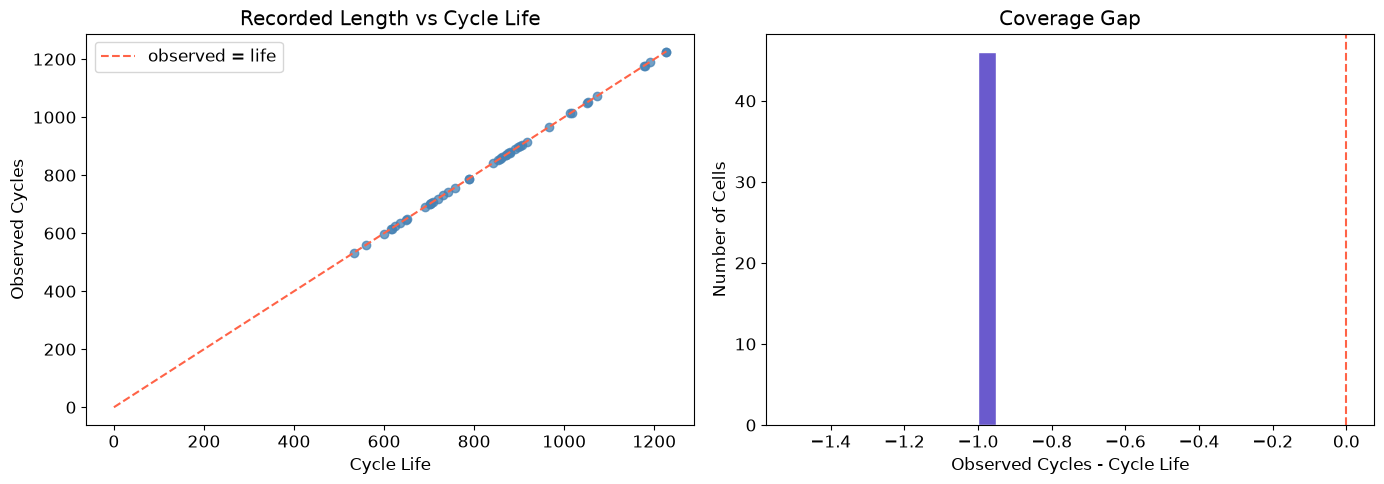

,observed_cycles,cycle_life,coverage_gap
count,46.0,46.0,46.0
mean,843.7,844.7,-1.0
std,184.6,184.6,0.0
min,533.0,534.0,-1.0
25%,702.2,703.2,-1.0
50%,857.5,858.5,-1.0
75%,913.2,914.2,-1.0
max,1226.0,1227.0,-1.0


In [18]:
# 셀별 실제 관측 사이클 수와 cycle_life 비교
cell_coverage = df.groupby('cell_id').agg(
    observed_cycles=('cycle', 'max'),
    cycle_life=('cycle_life', 'first'),
    charging_policy=('charging_policy', 'first'),
).reset_index()
cell_coverage['coverage_gap'] = cell_coverage['observed_cycles'] - cell_coverage['cycle_life']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(cell_coverage['cycle_life'], cell_coverage['observed_cycles'],
                color='steelblue', alpha=0.75)
limit = max(cell_coverage['cycle_life'].max(), cell_coverage['observed_cycles'].max())
axes[0].plot([0, limit], [0, limit], '--', color='tomato', label='observed = life')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('Observed Cycles')
axes[0].set_title('Recorded Length vs Cycle Life')
axes[0].legend()

axes[1].hist(cell_coverage['coverage_gap'], bins=20, color='slateblue', edgecolor='white')
axes[1].axvline(0, color='tomato', linestyle='--')
axes[1].set_xlabel('Observed Cycles - Cycle Life')
axes[1].set_ylabel('Number of Cells')
axes[1].set_title('Coverage Gap')
plt.tight_layout()
plt.show()

cell_coverage[['observed_cycles', 'cycle_life', 'coverage_gap']].describe().round(1)


[plot]
- 왼쪽 산점도의 붉은 점선은 실제 관측 사이클 수와 `cycle_life`가 같은 지점이다. 점이 선 위에 가까울수록 두 값의 차이가 작다.
- 점선 위쪽은 수명 시점 이후의 기록도 포함된 셀, 아래쪽은 `cycle_life`보다 기록이 짧은 셀을 뜻한다. 아래쪽 셀이 있다면 데이터 누락이나 두 변수의 정의 차이를 확인해야 한다.
- 오른쪽 `coverage_gap`은 `observed_cycles - cycle_life`다. 0을 중심으로 얼마나 퍼져 있는지 보면 셀마다 추가 기록 길이가 일정한지 확인할 수 있다.
- 아래 요약 통계의 최솟값, 중앙값, 최댓값을 함께 보면 일부 셀만 큰 차이를 보이는지 전체적으로 비슷한 차이가 있는지 구분할 수 있다.


### 3. 열화 곡선 - 방전 용량(QD) 감소 패턴

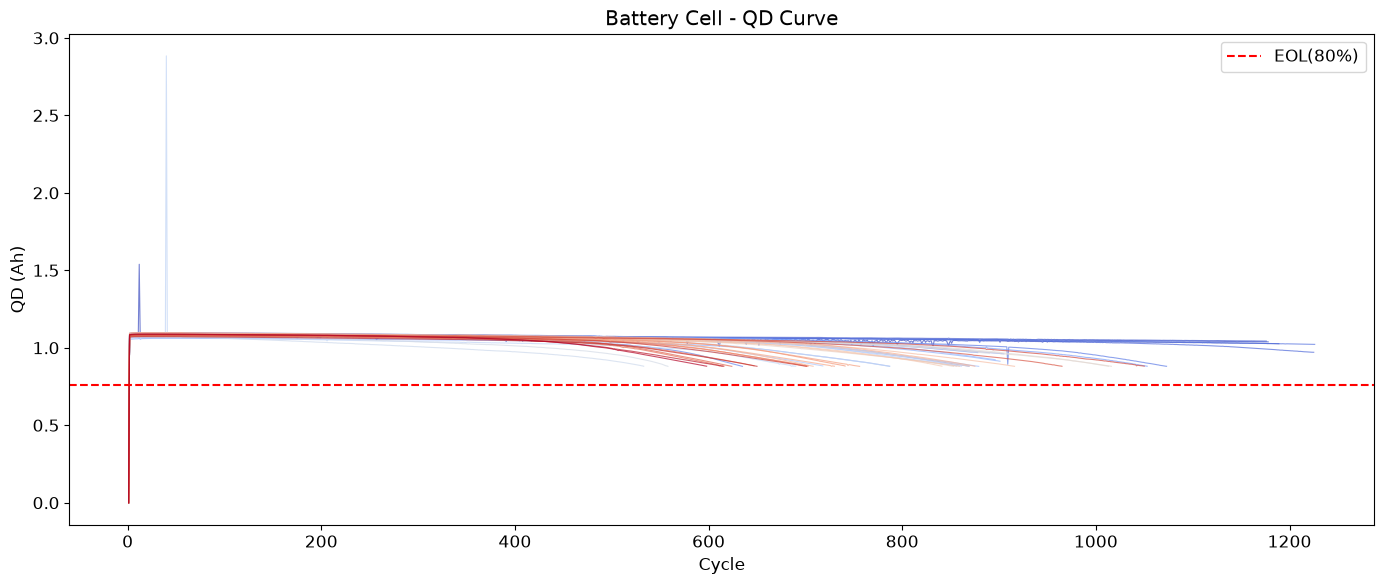

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

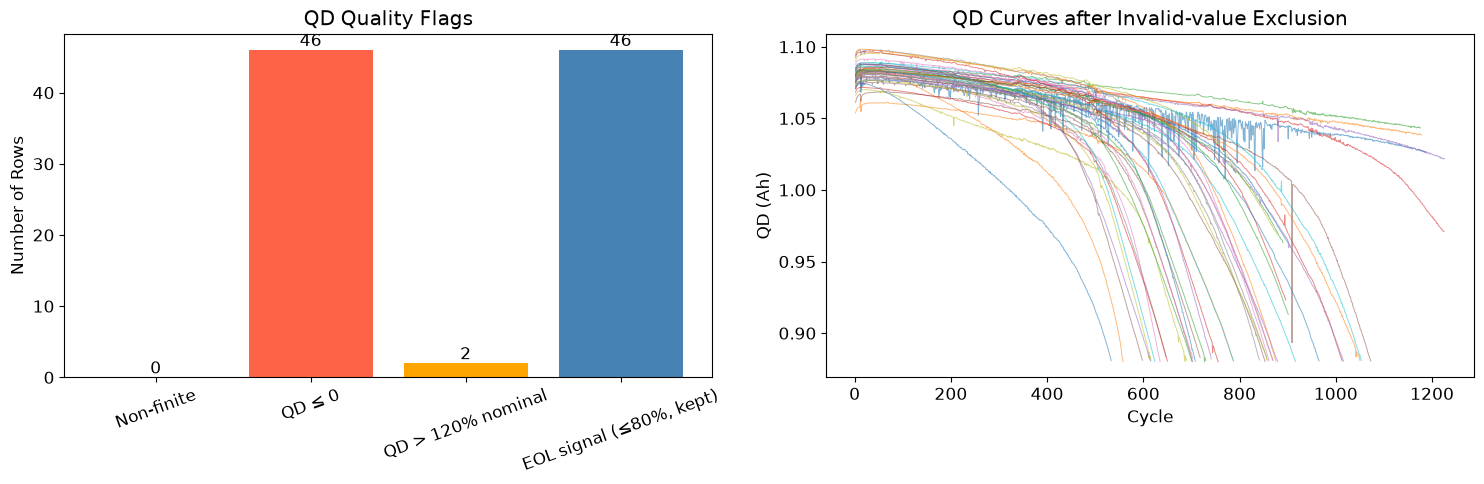

원본 행 수: 38,811
분석 제외 행 수: 48
유효 행 수: 38,763


,rows
Non-finite,0
QD ≤ 0,46
QD > 120% nominal,2
"EOL signal (≤80%, kept)",46


In [20]:
# QD 품질 기준 확정: 원본은 보존하고 분석 제외 사유를 플래그로 관리
df_raw = df.copy()

# 첫 사이클의 0값 영향을 피하기 위해 셀별 2~10사이클 중앙값을 초기 공칭 용량으로 사용
cell_nominal = (df_raw[df_raw['cycle'].between(2, 10)]
                .groupby('cell_id')['QD'].median()
                .rename('nominal_QD'))
df_flagged = df_raw.join(cell_nominal, on='cell_id')

df_flagged['invalid_nonfinite'] = ~np.isfinite(df_flagged['QD'])
df_flagged['invalid_nonpositive'] = df_flagged['QD'] <= 0
df_flagged['invalid_upper_spike'] = df_flagged['QD'] > df_flagged['nominal_QD'] * 1.20
df_flagged['eol_or_below'] = df_flagged['QD'] <= df_flagged['nominal_QD'] * 0.80
df_flagged['invalid_QD'] = df_flagged[[
    'invalid_nonfinite', 'invalid_nonpositive', 'invalid_upper_spike'
]].any(axis=1)

# 80% 이하 값은 실제 열화 신호일 수 있으므로 invalid_QD에 포함하지 않는다.
df_valid = df_flagged.loc[~df_flagged['invalid_QD']].copy()
df_clean = df_valid  # 이후 기존 셀과의 호환용 별칭

flag_summary = pd.Series({
    'Non-finite': int(df_flagged['invalid_nonfinite'].sum()),
    'QD ≤ 0': int(df_flagged['invalid_nonpositive'].sum()),
    'QD > 120% nominal': int(df_flagged['invalid_upper_spike'].sum()),
    'EOL signal (≤80%, kept)': int(df_flagged['eol_or_below'].sum()),
}, name='rows')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
flag_colors = ['gray', 'tomato', 'orange', 'steelblue']
bars = axes[0].bar(flag_summary.index, flag_summary.values, color=flag_colors)
for bar, value in zip(bars, flag_summary.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, value, str(value),
                 ha='center', va='bottom')
axes[0].set_ylabel('Number of Rows')
axes[0].set_title('QD Quality Flags')
axes[0].tick_params(axis='x', rotation=20)

for cid, sub in df_valid.groupby('cell_id'):
    axes[1].plot(sub['cycle'], sub['QD'], linewidth=0.7, alpha=0.55)
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('QD (Ah)')
axes[1].set_title('QD Curves after Invalid-value Exclusion')
plt.tight_layout()
plt.show()

print(f'원본 행 수: {len(df_raw):,}')
print(f'분석 제외 행 수: {df_flagged["invalid_QD"].sum():,}')
print(f'유효 행 수: {len(df_valid):,}')
display(flag_summary.to_frame())


[quality rule]
- 첫 사이클에는 QD·온도·내부 저항 등이 모두 0인 초기화 기록이 포함돼 있으므로 공칭 용량 계산에서 제외한다. 셀별 2~10사이클 QD 중앙값을 초기 공칭 용량으로 사용한다.
- `QD ≤ 0`, 유한하지 않은 값, 셀별 공칭 용량의 120%를 초과한 값만 분석 제외 대상으로 표시한다. 원본 `df_raw`는 수정하지 않는다.
- 공칭 용량의 80% 이하 값은 EOL 또는 실제 열화 신호일 수 있으므로 제거하지 않는다. 파란 막대는 제거 건수가 아니라 유지된 EOL 후보 건수다.
- 왼쪽 그래프에서 제외 사유별 건수를 확인하고, 오른쪽 그래프에서 상한 스파이크가 사라진 뒤에도 말기 용량 감소가 유지되는지 확인한다. 기준을 적용한 후 특정 셀의 후반부가 통째로 사라진다면 상한이나 데이터 로딩 과정을 다시 점검해야 한다.
- Knee point 계산에는 `df_valid`의 이동 중앙값을 사용하지만, cycle life와 EOL 해석에는 평활화하지 않은 유효 QD를 사용한다.


#### Knee point 탐색

각 셀의 QD 곡선을 두 개의 직선 구간으로 나눴을 때 전체 오차가 가장 작아지는 지점을 Knee point 후보로 계산합니다. 시작·종료부의 영향을 줄이기 위해 전체 기록의 20~90% 구간만 탐색합니다.


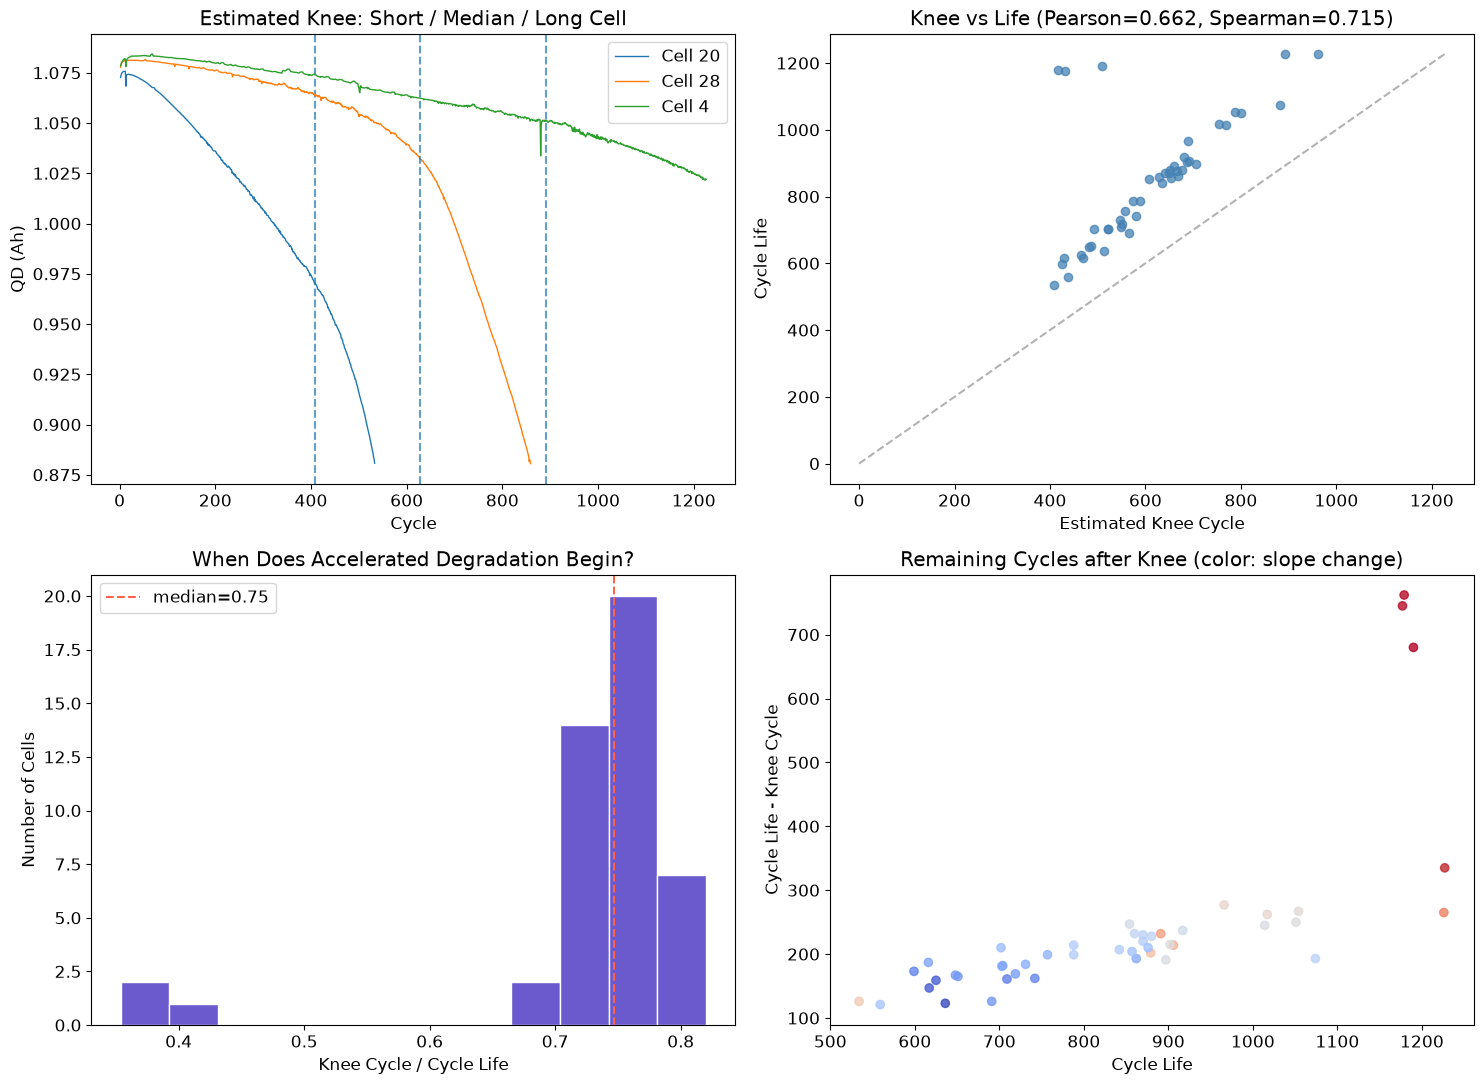

,knee_cycle,cycle_life,post_knee_life,knee_ratio,slope_before,slope_after
count,46.000,46.000,46.000,46.000,46.0,46.000
mean,607.804,844.717,236.913,0.729,-0.0,-0.001
std,132.459,184.629,138.748,0.096,0.0,0.000
min,408.000,534.000,121.000,0.354,-0.0,-0.001
25%,510.750,703.250,175.000,0.736,-0.0,-0.001
50%,598.000,858.500,205.500,0.747,-0.0,-0.001
75%,679.250,914.250,235.750,0.764,-0.0,-0.001
max,961.000,1227.000,762.000,0.820,-0.0,-0.000


In [21]:
def estimate_knee(sub, min_points=30, step=5):
    """QD를 두 선형 구간으로 나눴을 때 합산 오차가 최소인 변화점 추정."""
    work = sub[['cycle', 'QD']].dropna().sort_values('cycle').copy()
    work['QD_smooth'] = work['QD'].rolling(25, center=True, min_periods=5).median()
    work = work.dropna()
    x = work['cycle'].to_numpy(dtype=float)
    y = work['QD_smooth'].to_numpy(dtype=float)
    if len(work) < min_points * 2:
        return np.nan, np.nan, np.nan, np.nan
    start = max(min_points, int(len(x) * 0.20))
    stop = min(len(x) - min_points, int(len(x) * 0.90))
    best = None
    for split in range(start, stop, step):
        p1 = np.polyfit(x[:split], y[:split], 1)
        p2 = np.polyfit(x[split:], y[split:], 1)
        sse = np.square(y[:split] - np.polyval(p1, x[:split])).sum()
        sse += np.square(y[split:] - np.polyval(p2, x[split:])).sum()
        if best is None or sse < best[0]:
            best = (sse, split, p1[0], p2[0])
    _, split, slope_before, slope_after = best
    return x[split], slope_before, slope_after, slope_after - slope_before

knee_records = []
for cid, sub in df_valid.groupby('cell_id'):
    knee_cycle, slope_before, slope_after, slope_change = estimate_knee(sub)
    cycle_life = sub['cycle_life'].iloc[0]
    knee_records.append({
        'cell_id': cid, 'knee_cycle': knee_cycle, 'cycle_life': cycle_life,
        'slope_before': slope_before, 'slope_after': slope_after,
        'slope_change': slope_change,
        'post_knee_life': cycle_life - knee_cycle,
        'knee_ratio': knee_cycle / cycle_life,
    })
knee_df = pd.DataFrame(knee_records).dropna()
pearson_r = knee_df['knee_cycle'].corr(knee_df['cycle_life'], method='pearson')
spearman_r = knee_df['knee_cycle'].corr(knee_df['cycle_life'], method='spearman')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
sample_ids = cycle_life_df.sort_values('cycle_life').iloc[[0, len(cycle_life_df)//2, -1]]['cell_id']
for cid in sample_ids:
    sub = df_valid[df_valid['cell_id'] == cid]
    knee = knee_df.loc[knee_df['cell_id'] == cid, 'knee_cycle'].iloc[0]
    axes[0, 0].plot(sub['cycle'], sub['QD'], linewidth=1, label=f'Cell {cid}')
    axes[0, 0].axvline(knee, linestyle='--', alpha=0.7)
axes[0, 0].set_xlabel('Cycle'); axes[0, 0].set_ylabel('QD (Ah)')
axes[0, 0].set_title('Estimated Knee: Short / Median / Long Cell')
axes[0, 0].legend()

axes[0, 1].scatter(knee_df['knee_cycle'], knee_df['cycle_life'], color='steelblue', alpha=0.75)
limit = max(knee_df['knee_cycle'].max(), knee_df['cycle_life'].max())
axes[0, 1].plot([0, limit], [0, limit], '--', color='gray', alpha=0.6)
axes[0, 1].set_xlabel('Estimated Knee Cycle'); axes[0, 1].set_ylabel('Cycle Life')
axes[0, 1].set_title(f'Knee vs Life (Pearson={pearson_r:.3f}, Spearman={spearman_r:.3f})')

axes[1, 0].hist(knee_df['knee_ratio'], bins=12, color='slateblue', edgecolor='white')
axes[1, 0].axvline(knee_df['knee_ratio'].median(), color='tomato', linestyle='--',
                   label=f"median={knee_df['knee_ratio'].median():.2f}")
axes[1, 0].set_xlabel('Knee Cycle / Cycle Life')
axes[1, 0].set_ylabel('Number of Cells')
axes[1, 0].set_title('When Does Accelerated Degradation Begin?')
axes[1, 0].legend()

axes[1, 1].scatter(knee_df['cycle_life'], knee_df['post_knee_life'],
                   c=knee_df['slope_change'], cmap='coolwarm', alpha=0.8)
axes[1, 1].set_xlabel('Cycle Life'); axes[1, 1].set_ylabel('Cycle Life - Knee Cycle')
axes[1, 1].set_title('Remaining Cycles after Knee (color: slope change)')
plt.tight_layout()
plt.show()

display(knee_df[['knee_cycle', 'cycle_life', 'post_knee_life',
                 'knee_ratio', 'slope_before', 'slope_after']].describe().round(3))


[plot]
- 왼쪽 위는 수명이 짧은 셀·중앙 셀·긴 셀에서 추정 Knee가 실제 곡선의 급격한 하강 시작점과 겹치는지 확인하는 진단 그래프다. 세 사례에서 위치가 부자연스럽다면 상관계수를 해석하기 전에 추정 방식을 조정해야 한다.
- 오른쪽 위는 Knee가 늦게 나타나는 셀일수록 전체 수명도 긴지 보여준다. Pearson은 선형 관계, Spearman은 순위 관계를 나타낸다. 두 값이 함께 크면 관계가 특정 이상치 하나에만 의존할 가능성이 낮다.
- 왼쪽 아래의 `knee_ratio`는 전체 수명의 어느 비율에서 가속 열화가 시작됐는지 나타낸다. 한 구간에 모이면 셀들이 수명의 비슷한 시점에 Knee를 겪는다는 뜻이고, 넓게 퍼지면 충전 정책별 차이를 추가로 확인해야 한다.
- 오른쪽 아래의 `post_knee_life`는 Knee 이후 종료까지 남은 사이클이다. 이 값이 일정하면 Knee가 EOL의 선행 지표가 될 수 있고, 수명에 따라 커진다면 Knee 이후 열화 속도도 셀마다 다르다는 의미다.
- Knee는 전체 수명 곡선을 사용해 계산하므로 cycle life와 높은 상관이 나와도 조기 예측 피처라고 볼 수 없다. 여기서는 열화 구조를 설명하는 진단값으로 사용한다.


### 4. ΔQ(V) — 초기 사이클 차이

사이클 10과 100의 방전 Q(V)를 공통 전압 축에 보간한 뒤 `Q₁₀₀(V)-Q₁₀(V)`를 계산합니다. `<500` 셀이 없으므로 비교 그래프에서는 하위 25%를 ‘상대적 단수명 그룹’으로 표시합니다. 이는 원래의 `<500` 기준을 대체한 결과가 아니라 Batch1 내부 비교용 기준입니다.


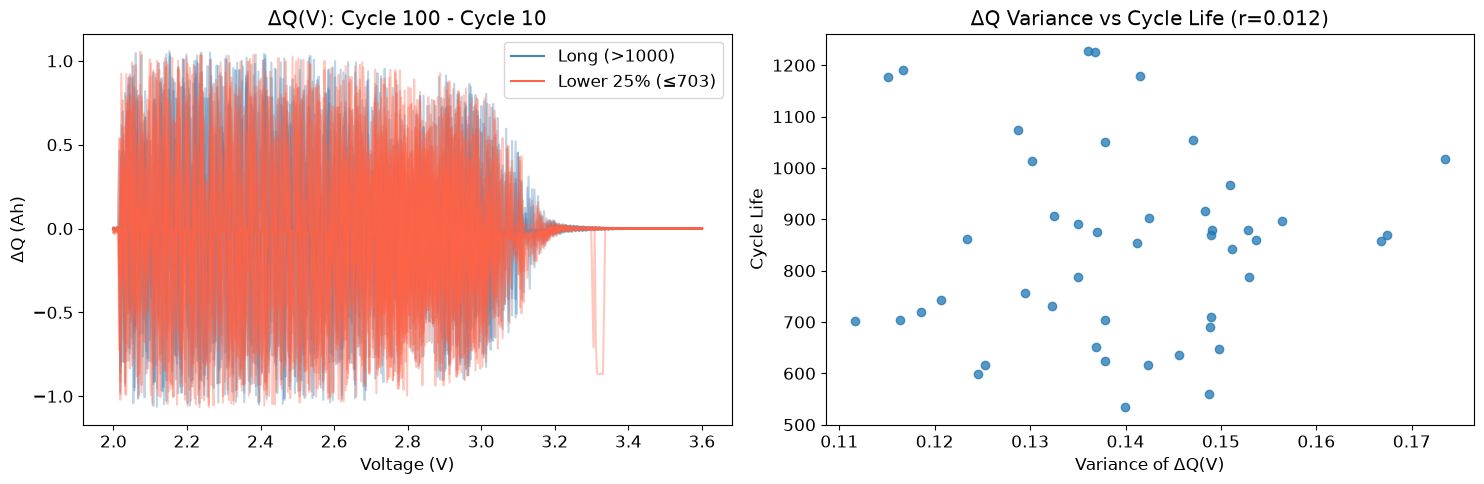

cycle_life     1.000
cell_id       -0.602
dq_mean        0.580
dq_min         0.046
dq_variance    0.012
dq_area_abs   -0.012
Name: cycle_life, dtype: float64

In [22]:
def cycle_array(cell, field, cycle_number):
    values = cell['cycles'].get(field) if isinstance(cell['cycles'], dict) else None
    if values is None or len(values) < cycle_number:
        return None
    value = values[cycle_number - 1]
    if value is None:
        return None
    value = np.asarray(value, dtype=float).squeeze()
    return value if value.ndim == 1 and value.size > 3 else None

def delta_q_curve(cell, early_cycle=10, later_cycle=100, points=500):
    v10, q10 = cycle_array(cell, 'V', early_cycle), cycle_array(cell, 'Qd', early_cycle)
    v100, q100 = cycle_array(cell, 'V', later_cycle), cycle_array(cell, 'Qd', later_cycle)
    if any(value is None for value in [v10, q10, v100, q100]):
        return None
    def clean(v, q):
        valid = np.isfinite(v) & np.isfinite(q)
        frame = pd.DataFrame({'V': v[valid], 'Q': q[valid]}).groupby('V', as_index=False)['Q'].mean()
        return frame['V'].to_numpy(), frame['Q'].to_numpy()
    v10, q10 = clean(v10, q10)
    v100, q100 = clean(v100, q100)
    low, high = max(v10.min(), v100.min()), min(v10.max(), v100.max())
    if low >= high:
        return None
    voltage = np.linspace(low, high, points)
    delta_q = np.interp(voltage, v100, q100) - np.interp(voltage, v10, q10)
    return voltage, delta_q

dq_records, dq_curves = [], {}
for cid, cell in enumerate(batch):
    result = delta_q_curve(cell)
    if result is None:
        continue
    voltage, delta_q = result
    life = int(cell['cycle_life'])
    dq_curves[cid] = (voltage, delta_q)
    dq_records.append({
        'cell_id': cid, 'cycle_life': life,
        'dq_mean': delta_q.mean(), 'dq_min': delta_q.min(),
        'dq_variance': delta_q.var(),
        'dq_area_abs': np.trapezoid(np.abs(delta_q), voltage),
    })
dq_features = pd.DataFrame(dq_records)

if dq_features.empty:
    print('ΔQ(V)를 계산할 수 없습니다. cycles의 V/Qd 배열 로드 상태를 확인하세요.')
else:
    q1 = cycle_life_df['cycle_life'].quantile(0.25)
    long_ids = set(cycle_life_df.query('cycle_life > 1000')['cell_id']) & set(dq_curves)
    low_ids = set(cycle_life_df.query('cycle_life <= @q1')['cell_id']) & set(dq_curves)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for cid in sorted(long_ids):
        v, dq = dq_curves[cid]; axes[0].plot(v, dq, color='steelblue', alpha=0.35)
    for cid in sorted(low_ids):
        v, dq = dq_curves[cid]; axes[0].plot(v, dq, color='tomato', alpha=0.35)
    axes[0].plot([], [], color='steelblue', label='Long (>1000)')
    axes[0].plot([], [], color='tomato', label=f'Lower 25% (≤{q1:.0f})')
    axes[0].set_xlabel('Voltage (V)'); axes[0].set_ylabel('ΔQ (Ah)')
    axes[0].set_title('ΔQ(V): Cycle 100 - Cycle 10'); axes[0].legend()

    axes[1].scatter(dq_features['dq_variance'], dq_features['cycle_life'], alpha=0.75)
    dq_corr = dq_features['dq_variance'].corr(dq_features['cycle_life'])
    axes[1].set_xlabel('Variance of ΔQ(V)'); axes[1].set_ylabel('Cycle Life')
    axes[1].set_title(f'ΔQ Variance vs Cycle Life (r={dq_corr:.3f})')
    plt.tight_layout(); plt.show()
    display(dq_features.corr(numeric_only=True)['cycle_life'].sort_values(key=abs, ascending=False).round(3))


[plot]
- 왼쪽에서 두 집단의 곡선 위치와 형태가 분리되면, 전체 용량이 비슷한 초기 구간에도 열화 신호가 존재한다는 뜻이다.
- 오른쪽은 ΔQ(V) 분산과 수명의 관계를 셀 단위로 확인한다. 상관계수의 절댓값이 클수록 조기 수명 피처 후보로 검토할 근거가 생긴다.
- 전압 범위와 측정 지점 수가 셀마다 다르므로 반드시 공통 전압 구간에 보간해야 한다. 계산 가능한 셀만 남으므로 제외된 셀 수 역시 확인해야 한다.


#### ΔQ(V) 계산 가능 여부와 피처 분리력 확인

ΔQ(V) 해석 전에 사이클 10·100의 V/Qd가 실제로 읽힌 셀 수를 확인합니다. 계산 가능한 셀만으로 결과를 만들면 특정 수명군이 더 많이 제외될 수 있으므로 그룹별 성공률도 함께 봅니다.


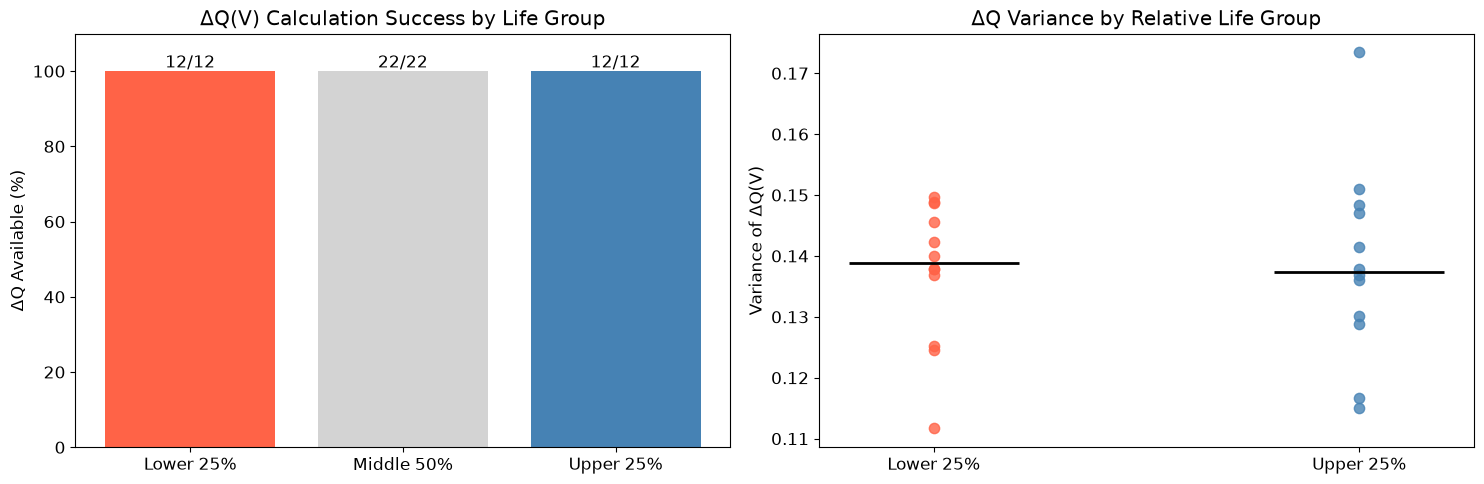

,sum,count,rate_pct
relative_group,,,
Lower 25%,12,12,100.0
Middle 50%,22,22,100.0
Upper 25%,12,12,100.0


dq_mean          dq_min          dq_variance           \
                 count   median  count   median       count   median   
relative_group                                                         
Lower 25%           12 -0.01830     12 -1.04479          12  0.13890   
Middle 50%          22 -0.01123     22 -1.04573          22  0.14184   
Upper 25%           12  0.00077     12 -1.04964          12  0.13732   

               dq_area_abs           
                     count   median  
relative_group                       
Lower 25%               12  0.38093  
Middle 50%              22  0.38275  
Upper 25%               12  0.37466

In [23]:
# ΔQ(V) 계산 성공률과 상대 수명군별 피처 비교
dq_available = relative_life[['cell_id', 'cycle_life', 'relative_group']].copy()
dq_available['dq_available'] = dq_available['cell_id'].isin(dq_features['cell_id']) if not dq_features.empty else False
availability = (dq_available.groupby('relative_group', observed=False)['dq_available']
                .agg(['sum', 'count']).reindex(group_order))
availability['rate_pct'] = availability['sum'].div(availability['count']).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].bar(availability.index, availability['rate_pct'],
                   color=['tomato', 'lightgray', 'steelblue'])
for bar, (_, row) in zip(bars, availability.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{int(row['sum'])}/{int(row['count'])}", ha='center')
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('ΔQ Available (%)')
axes[0].set_title('ΔQ(V) Calculation Success by Life Group')

if dq_features.empty:
    axes[1].text(0.5, 0.5, 'No ΔQ(V) feature available', ha='center', va='center')
    axes[1].set_axis_off()
else:
    dq_compare = dq_features.merge(relative_life[['cell_id', 'relative_group']], on='cell_id')
    compare_groups = ['Lower 25%', 'Upper 25%']
    feature = 'dq_variance'
    for x, (group, color) in enumerate(zip(compare_groups, ['tomato', 'steelblue'])):
        values = dq_compare.loc[dq_compare['relative_group'] == group, feature]
        axes[1].scatter(np.full(len(values), x), values, color=color, alpha=0.8, s=55)
        if len(values):
            axes[1].hlines(values.median(), x - 0.2, x + 0.2, color='black', linewidth=2)
    axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(compare_groups)
    axes[1].set_ylabel('Variance of ΔQ(V)')
    axes[1].set_title('ΔQ Variance by Relative Life Group')
plt.tight_layout(); plt.show()
display(availability.round(1))
if not dq_features.empty:
    display(dq_compare.groupby('relative_group', observed=False)[
        ['dq_mean', 'dq_min', 'dq_variance', 'dq_area_abs']].agg(['count', 'median']).round(5))


[check & plot]
- 왼쪽 성공률이 그룹마다 다르면 ΔQ 결과에 선택 편향이 생긴다. 특히 한 그룹의 계산 성공률이 낮으면 곡선 차이를 수명 차이로 해석하면 안 된다.
- 계산 성공률이 낮을 때는 피처 분석보다 HDF5의 `cycles/V`, `cycles/Qd` 참조를 정상적으로 읽는 로더를 먼저 수정해야 한다.
- 오른쪽 그래프는 Batch1 하위·상위 25%의 ΔQ 분산을 비교한다. 두 집단의 중앙값뿐 아니라 점의 겹침과 그룹별 표본 수도 함께 본다.
- ΔQ 피처와 수명의 상관이 크더라도 사이클 10·100의 전압 범위, 보간점 수, 누락 셀이 바뀌었을 때 결과가 유지되는지 확인해야 한다.


### 5. 내부 저항(IR) 변화 - 열화 지표

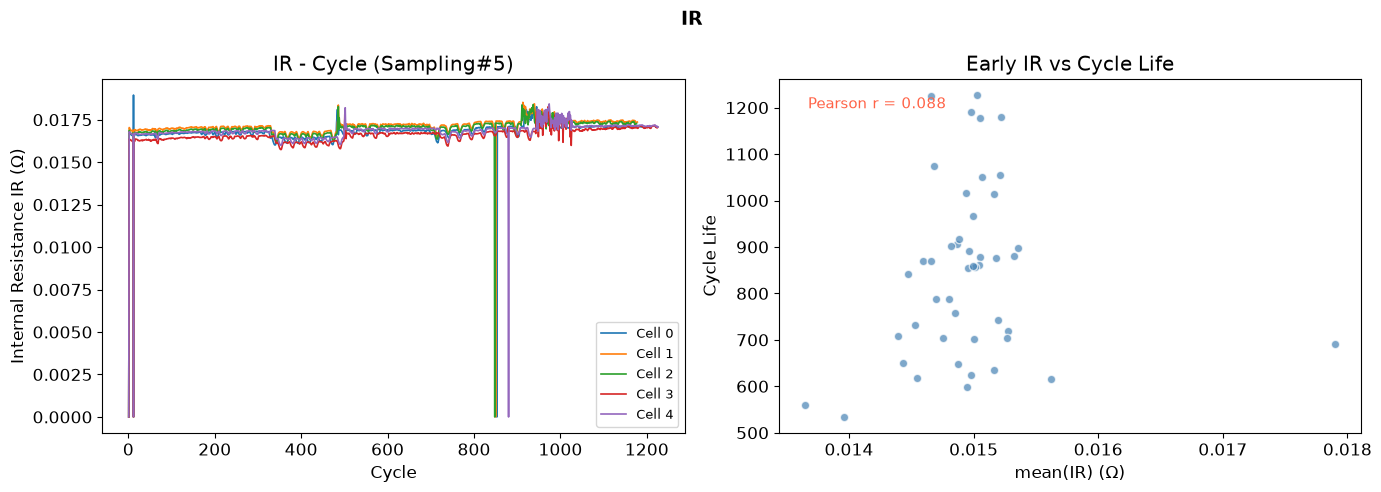

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 6. 충전 정책(C-rate)과 수명의 관계

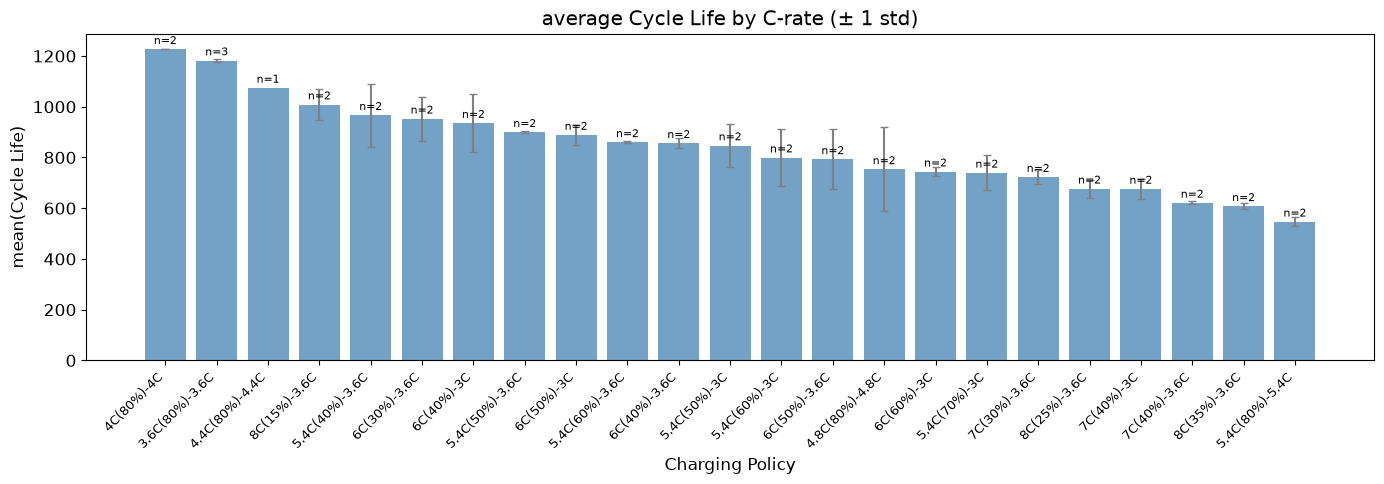

In [25]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

#### C-rate 구성 요소별 비교

충전 프로토콜 이름을 1단계 C-rate, 전환 SOC, 2단계 C-rate로 분리합니다. 전체 문자열별 평균만 비교하면 어느 조건이 수명 차이와 연결되는지 알기 어렵기 때문입니다.


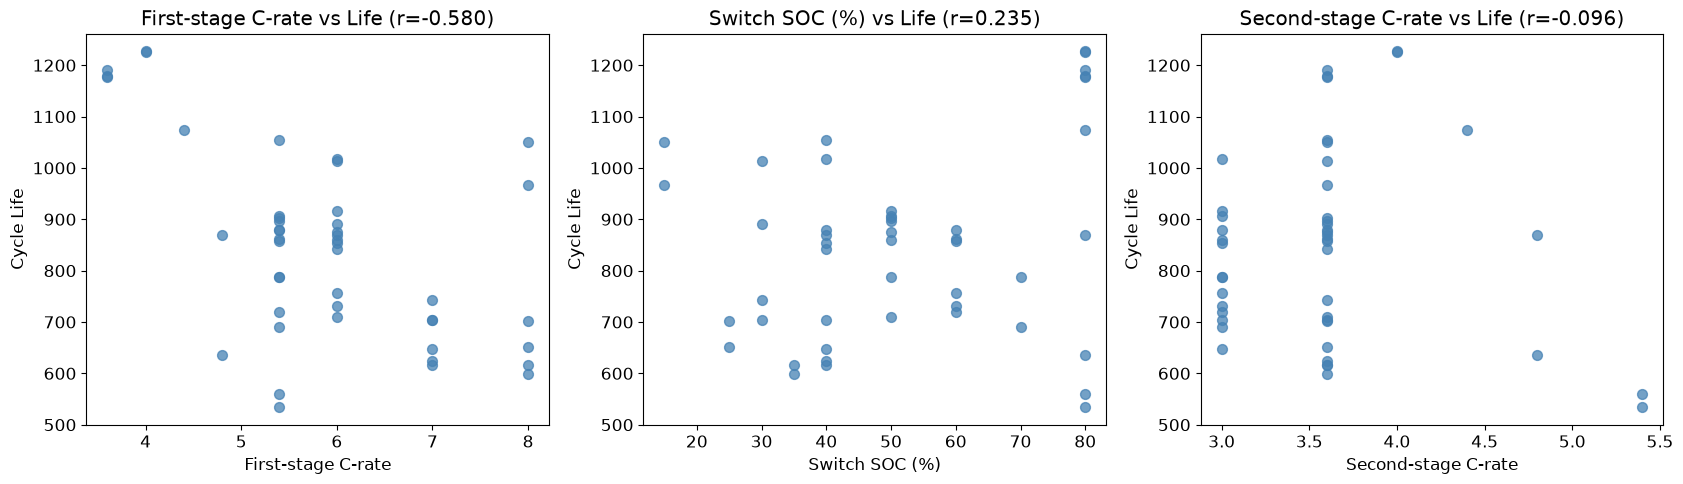

,corr_with_cycle_life
first_C,-0.580
switch_SOC,0.235
second_C,-0.096


count    mean    std
first_C switch_SOC second_C                      
4.0     80.0       4.0           2  1226.5    0.7
3.6     80.0       3.6           3  1182.0    7.0
4.4     80.0       4.4           1  1074.0    NaN
8.0     15.0       3.6           2  1008.5   60.1
5.4     40.0       3.6           2   966.5  123.7
6.0     30.0       3.6           2   952.5   87.0
        40.0       3.0           2   935.5  115.3
5.4     50.0       3.6           2   899.5    3.5
6.0     50.0       3.0           2   888.5   40.3
5.4     60.0       3.6           2   859.5    3.5
6.0     40.0       3.6           2   856.0   19.8
5.4     50.0       3.0           2   847.0   83.4
        60.0       3.0           2   799.5  113.8
6.0     50.0       3.6           2   792.5  118.1
4.8     80.0       4.8           2   753.0  165.5
6.0     60.0       3.0           2   744.0   18.4
5.4     70.0       3.0           2   739.5   68.6
7.0     30.0       3.6           2   722.5   27.6
8.0     25.0       3.6           2   676.5   36.1
7.0     40.0       3.0           2   676.0   39.6
                   3.6           2   621.0    5.7
8.0     35.0       3.6           2   607.5   12.0
5.4     80.0       5.4           2   546.5   17.7

In [26]:
import re

def parse_policy(text):
    match = re.fullmatch(r'([0-9.]+)C\(([0-9.]+)%\)-([0-9.]+)C', str(text))
    if match is None:
        return pd.Series([np.nan, np.nan, np.nan],
                         index=['first_C', 'switch_SOC', 'second_C'])
    return pd.Series([float(value) for value in match.groups()],
                     index=['first_C', 'switch_SOC', 'second_C'])

policy_components = cycle_life_df.copy()
policy_components[['first_C', 'switch_SOC', 'second_C']] = (
    policy_components['charging_policy'].apply(parse_policy)
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
components = [('first_C', 'First-stage C-rate'),
              ('switch_SOC', 'Switch SOC (%)'),
              ('second_C', 'Second-stage C-rate')]
for ax, (column, label) in zip(axes, components):
    ax.scatter(policy_components[column], policy_components['cycle_life'],
               color='steelblue', alpha=0.75, s=50)
    corr = policy_components[column].corr(policy_components['cycle_life'])
    ax.set_xlabel(label); ax.set_ylabel('Cycle Life')
    ax.set_title(f'{label} vs Life (r={corr:.3f})')
plt.tight_layout(); plt.show()

component_corr = policy_components[[
    'cycle_life', 'first_C', 'switch_SOC', 'second_C'
]].corr()['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False)
display(component_corr.rename('corr_with_cycle_life').round(3).to_frame())
display(policy_components.groupby(['first_C', 'switch_SOC', 'second_C'])['cycle_life']
        .agg(['count', 'mean', 'std']).sort_values('mean', ascending=False).round(1))


[plot]
- 세 산점도는 1단계 속도, 전환 SOC, 2단계 속도 중 어느 구성 요소가 수명과 더 뚜렷한 관계를 보이는지 분리해서 확인한다.
- 동일한 C-rate 값에 여러 점이 겹치므로 상관계수만 보지 않고 수직 방향의 수명 편차를 함께 확인한다. 편차가 크면 다른 단계 조건이나 온도의 영향이 남아 있다는 뜻이다.
- 정책 조합별 `count`가 작으면 평균과 표준편차가 불안정하다. 이 그래프는 인과효과가 아니라 다음 모델에 넣을 조건을 고르는 탐색 분석이다.


#### 충전 시간·온도와 수명의 관계

충전 정책 그래프에서 보인 차이가 충전 시간과 초기 온도에서도 나타나는지 셀 단위로 확인합니다.


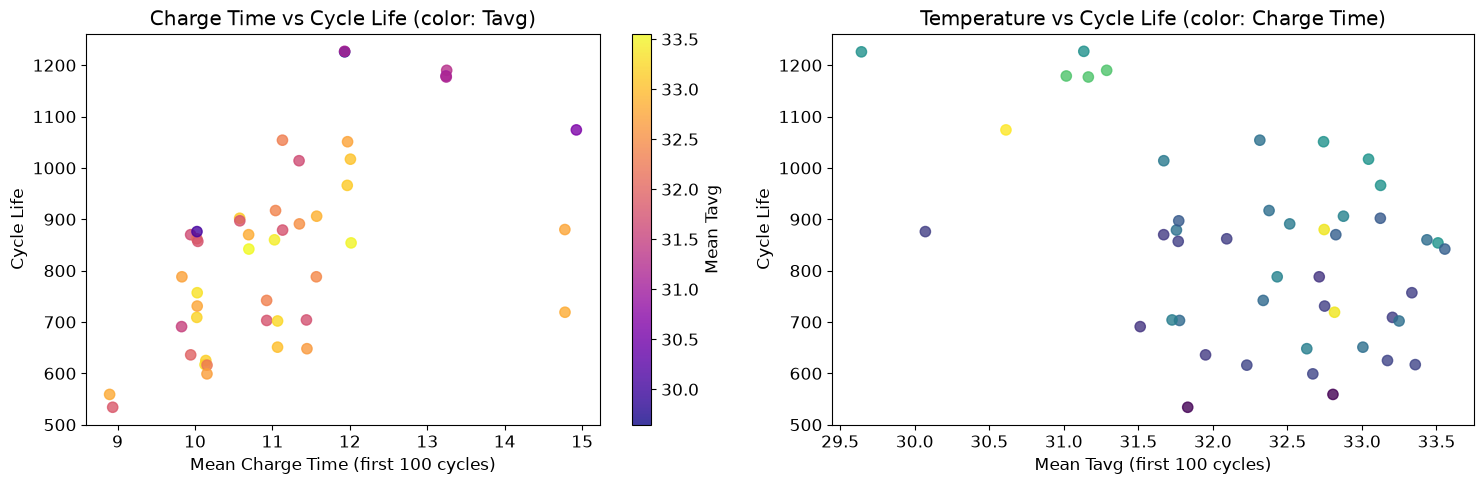

,cycle_life,mean_chargetime,mean_Tavg
cycle_life,1.000,0.577,-0.482
mean_chargetime,0.577,1.000,-0.199
mean_Tavg,-0.482,-0.199,1.000


In [27]:
charge_temp = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life=('cycle_life', 'first'),
    mean_chargetime=('chargetime', 'mean'),
    mean_Tavg=('Tavg', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
scatter = axes[0].scatter(charge_temp['mean_chargetime'], charge_temp['cycle_life'],
                          c=charge_temp['mean_Tavg'], cmap='plasma', s=55, alpha=0.8)
axes[0].set_xlabel('Mean Charge Time (first 100 cycles)')
axes[0].set_ylabel('Cycle Life')
axes[0].set_title('Charge Time vs Cycle Life (color: Tavg)')
plt.colorbar(scatter, ax=axes[0], label='Mean Tavg')

axes[1].scatter(charge_temp['mean_Tavg'], charge_temp['cycle_life'],
                c=charge_temp['mean_chargetime'], cmap='viridis', s=55, alpha=0.8)
axes[1].set_xlabel('Mean Tavg (first 100 cycles)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Temperature vs Cycle Life (color: Charge Time)')
plt.tight_layout(); plt.show()

charge_temp[['cycle_life', 'mean_chargetime', 'mean_Tavg']].corr().round(3)


[plot]
- 충전 시간과 수명의 양의 관계가 온도 색상에 따라 나뉘는지 보면 충전 속도와 발열이 함께 움직이는 정도를 확인할 수 있다.
- 온도와 수명의 음의 관계가 충전 시간에 따라 달라진다면 두 변수의 효과가 섞여 있을 수 있다. 산점도만으로 어느 변수가 원인인지 구분할 수는 없다.
- 이후 회귀모델에서는 충전 정책·충전 시간·온도를 함께 넣고, 한 변수를 추가했을 때 설명력이 실제로 증가하는지 비교해야 한다.


### 7. 상관관계 — 어떤 초기 신호가 수명과 연관되어 있는가?


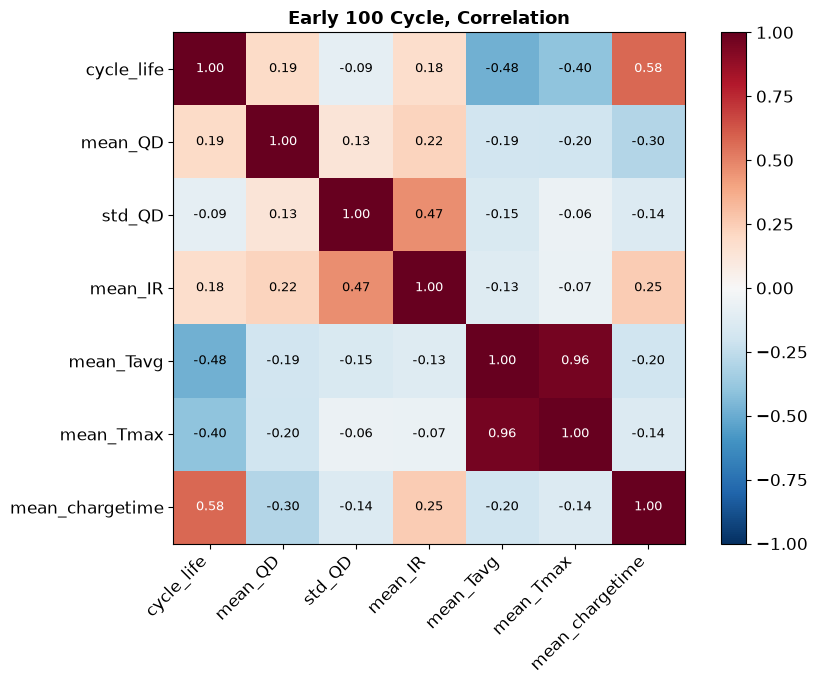


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [28]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

#### 타깃 상관과 멀티콜리니어리티 점검

Cycle Life와의 상관이 큰 피처를 순위로 확인하고, 피처끼리 같은 정보를 반복해서 담는지는 VIF로 별도 점검합니다.


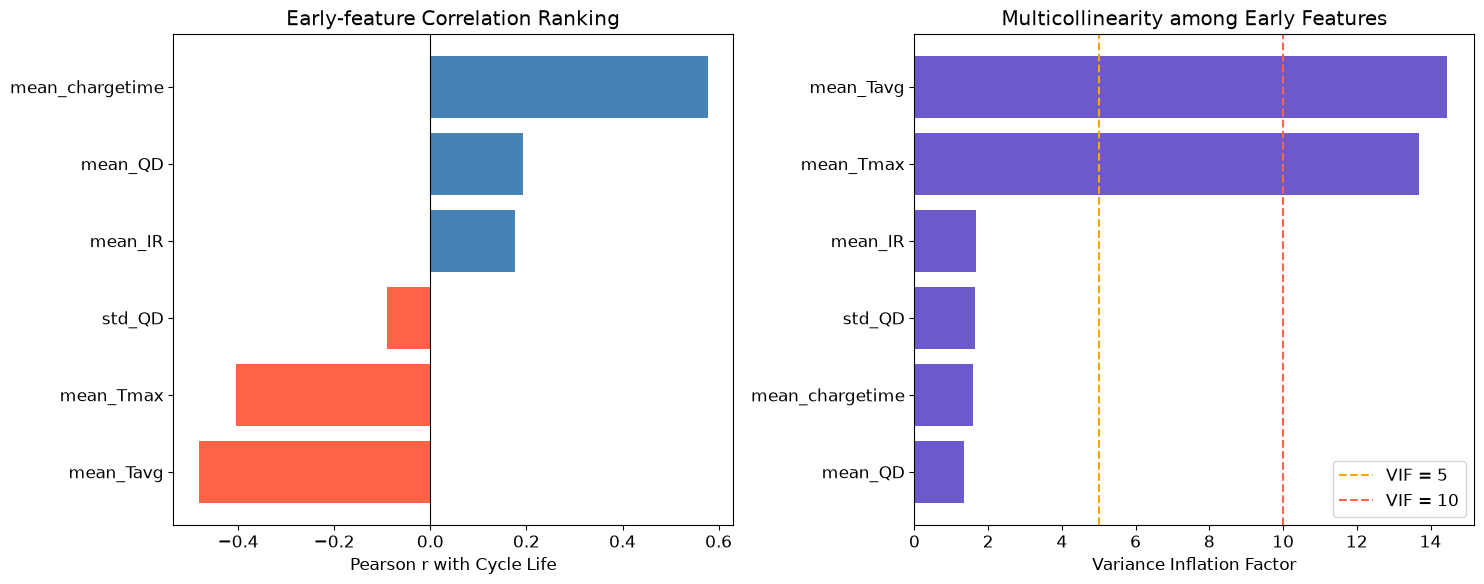

[가장 강한 초기 신호]
mean_chargetime: Pearson r=0.577, Spearman r=0.613

[Cycle Life 상관계수 순위]


,pearson_r,spearman_r
mean_chargetime,0.577,0.613
mean_Tavg,-0.482,-0.371
mean_Tmax,-0.404,-0.323
mean_QD,0.193,0.185
mean_IR,0.177,0.136
std_QD,-0.090,0.237



[절댓값 0.80 이상인 피처 간 상관쌍]


,feature_1,feature_2,pearson_r
22,mean_Tavg,mean_Tmax,0.956



[VIF]


,VIF
mean_Tavg,14.456
mean_Tmax,13.699
mean_IR,1.659
std_QD,1.631
mean_chargetime,1.589
mean_QD,1.333


In [29]:
feature_cols = [c for c in early.columns if c != 'cycle_life']

# Pearson: 선형 관계, Spearman: 순위 기반 단조 관계
pearson_corr = early[feature_cols + ['cycle_life']].corr(method='pearson')['cycle_life'].drop('cycle_life')
spearman_corr = early[feature_cols + ['cycle_life']].corr(method='spearman')['cycle_life'].drop('cycle_life')
correlation_rank = pd.DataFrame({
    'pearson_r': pearson_corr,
    'spearman_r': spearman_corr,
})
correlation_rank['abs_pearson'] = correlation_rank['pearson_r'].abs()
correlation_rank = correlation_rank.sort_values('abs_pearson', ascending=False)
strongest_feature = correlation_rank.index[0]

def calculate_vif(frame):
    X = frame.astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    X = (X - X.mean()) / X.std(ddof=0)
    result = {}
    for column in X.columns:
        y = X[column].to_numpy()
        others = X.drop(columns=column).to_numpy()
        design = np.column_stack([np.ones(len(others)), others])
        fitted = design @ np.linalg.lstsq(design, y, rcond=None)[0]
        ss_res = np.square(y - fitted).sum()
        ss_tot = np.square(y - y.mean()).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot else 1.0
        result[column] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name='VIF').sort_values(ascending=False)

vif = calculate_vif(early[feature_cols])
feature_corr = early[feature_cols].corr(method='pearson')
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
high_corr_pairs = (feature_corr.where(upper_mask).stack()
                   .rename('pearson_r').reset_index())
high_corr_pairs.columns = ['feature_1', 'feature_2', 'pearson_r']
high_corr_pairs = (high_corr_pairs[high_corr_pairs['pearson_r'].abs() >= 0.80]
                   .assign(abs_r=lambda x: x['pearson_r'].abs())
                   .sort_values('abs_r', ascending=False)
                   .drop(columns='abs_r'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_rank = correlation_rank.sort_values('pearson_r')
colors = ['tomato' if value < 0 else 'steelblue' for value in plot_rank['pearson_r']]
axes[0].barh(plot_rank.index, plot_rank['pearson_r'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Pearson r with Cycle Life')
axes[0].set_title('Early-feature Correlation Ranking')

vif_plot = vif.replace(np.inf, np.nan).sort_values()
axes[1].barh(vif_plot.index, vif_plot.values, color='slateblue')
axes[1].axvline(5, color='orange', linestyle='--', label='VIF = 5')
axes[1].axvline(10, color='tomato', linestyle='--', label='VIF = 10')
axes[1].set_xlabel('Variance Inflation Factor')
axes[1].set_title('Multicollinearity among Early Features')
axes[1].legend()
plt.tight_layout(); plt.show()

print('[가장 강한 초기 신호]')
print(f'{strongest_feature}: Pearson r={correlation_rank.loc[strongest_feature, "pearson_r"]:.3f}, '
      f'Spearman r={correlation_rank.loc[strongest_feature, "spearman_r"]:.3f}')
print('\n[Cycle Life 상관계수 순위]')
display(correlation_rank[['pearson_r', 'spearman_r']].round(3))
print('\n[절댓값 0.80 이상인 피처 간 상관쌍]')
display(high_corr_pairs.round(3) if not high_corr_pairs.empty else pd.DataFrame({'result': ['해당 없음']}))
print('\n[VIF]')
display(vif.round(3).to_frame())


[결론]
- **초기 사이클 피처와 Cycle Life의 상관:** 저장된 분석 결과에서 `mean_chargetime`이 Pearson `r=0.577`로 가장 강한 양의 관계를 보였다. 초기 100사이클의 평균 충전 시간이 긴 셀일수록 수명이 긴 방향이다.
- 다음으로 큰 관계는 `mean_Tavg`(`r=-0.482`)와 `mean_Tmax`(`r=-0.404`)다. 초기 온도가 높을수록 수명이 짧은 방향이다. `mean_QD`(0.193), `mean_IR`(0.177), `std_QD`(-0.090)는 단독 선형 관계가 상대적으로 약하다.
- Pearson과 Spearman을 함께 표시한다. 두 값의 방향과 크기가 비슷하면 관계가 일부 극단값에만 의존할 가능성이 낮다. 차이가 크면 비선형 관계나 이상값을 산점도로 다시 확인해야 한다.
- **가장 강한 관계:** 현재 피처 중에서는 `mean_chargetime`이다. 다만 충전 정책이 충전 시간과 온도에 동시에 영향을 줄 수 있으므로 충전 시간 자체의 인과효과로 단정하지 않는다.
- **멀티콜리니어리티:** 기존 상관행렬에서 `mean_Tavg`와 `mean_Tmax`의 상관계수는 0.96으로 같은 온도 정보를 많이 공유한다. 새 표는 절댓값 0.80 이상인 모든 피처 쌍을 자동으로 추출하고 VIF도 함께 보여준다.
- VIF가 5 이상이면 점검하고 10 이상이면 강한 중복 가능성을 검토한다. 이 기준으로 변수를 자동 삭제하지는 않는다. 의미가 겹치는 온도 피처는 하나를 선택하거나, 규제가 있는 모델을 사용한 뒤 교차검증 성능을 비교한다.

[시사점]
- 조기 수명 예측에는 충전 시간과 온도가 초기 QD나 IR보다 우선적인 후보로 보인다.
- 단순 상관은 충전 정책의 영향을 분리하지 못한다. 다음 모델에서는 충전 정책을 함께 통제한 뒤 각 피처가 추가 설명력을 제공하는지 확인해야 한다.
- 최종 피처 선택은 상관계수 순위만으로 결정하지 않고, 멀티콜리니어리티·비선형성·교차검증 결과를 함께 사용한다.


---
## 분석 결과와 시사점

### 1. Cycle Life 분포

Batch1의 46개 셀은 534~1,227 사이클에 분포한다. 평균은 844.7, 중앙값은 858.5 사이클이며, 절반의 셀이 703.2~914.2 사이에 모여 있다. 150~2,300 사이클 범위로 보더라도 Batch1의 실제 관측값은 이보다 좁은 구간에만 존재한다. 분포 중심은 800 사이클대이고, 1,100 사이클을 넘는 장수명 셀이 오른쪽 꼬리를 만든다.

장수명(>1,000)/단수명(<500) 기준을 그대로 적용하면 `cycle_life > 1,000`인 장수명 셀은 10개로 전체의 21.7%지만, `cycle_life < 500`인 단수명 셀은 0개다. 이 결과는 분석 실패가 아니라 Batch1의 범위를 보여주는 결과다. 다만 한쪽 집단이 비어 있으므로 이 기준만으로 장·단수명 특성을 비교할 수는 없다.

그래서 Batch1 내부 비교에는 분위수 기준을 별도로 사용했다. 하위 25%는 `cycle_life ≤ 703.2`, 상위 25%는 `cycle_life ≥ 914.2`이며, 각각 Batch1 내 상대적 단수명군과 상대적 장수명군으로 정의한다. 양 끝 집단의 표본 수가 비슷해 ΔQ(V), 충전 조건, 온도 차이를 비교하기에 적합하다. 이 명칭은 Batch1 안에서만 유효하며 전체 배터리에 적용되는 절대 기준은 아니다.

최솟값인 Cell 20은 534 사이클이며 충전 정책은 `5.4C(80%)-5.4C`다. 그다음으로 짧은 Cell 21도 같은 정책에서 559 사이클을 기록했다. 같은 정책이 하위 수명 셀에서 반복되지만, 표본 수와 온도 등 다른 조건을 통제하지 않았으므로 해당 정책이 원인이라고 단정할 수는 없다. Box plot의 1.5×IQR 기준에서는 최솟값과 최댓값 모두 경계 안에 있어 통계적 이상치로 분류되는 셀도 없다.

**시사점:** 전체 데이터셋을 설명할 때는 `<500`과 `>1,000` 기준을 유지하고 Batch1에는 단수명 셀이 없다고 보고한다. Batch1 내부의 패턴을 비교할 때는 하위·상위 25% 기준을 사용한다. 두 기준의 목적을 분리하면 데이터 한계를 숨기지 않으면서도 후속 비교를 진행할 수 있다.

### 2. 방전 용량 열화 곡선과 Knee point

대부분의 셀은 초기 약 1.06~1.10 Ah에서 시작한다. 초기 용량이 서로 비슷해 시작점만으로 수명 차이를 구분하기는 어렵다. 사이클이 누적되면서 QD가 완만하게 감소하고, 상대적으로 수명이 짧은 셀은 먼저 종료된다. 장수명 셀은 더 많은 사이클 동안 높은 QD를 유지한다.

초기 구간의 0값과 비정상적으로 큰 QD는 열화 곡선을 왜곡하므로 Knee 분석 전에 품질 기준을 확정했다. 셀별 2~10사이클 QD 중앙값을 초기 공칭 용량으로 정의하고, `QD ≤ 0`, 유한하지 않은 값, 공칭 용량의 120%를 초과한 값만 분석에서 제외한다. 공칭 용량의 80% 이하 값은 실제 말기 열화 또는 EOL 신호일 수 있으므로 유지한다. 원본은 `df_raw`, 품질 플래그가 붙은 자료는 `df_flagged`, 분석용 자료는 `df_valid`로 분리해 삭제 근거를 추적할 수 있게 했다.

품질 플래그 그래프에서는 제외 사유별 행 수와 EOL 후보 행 수를 따로 보여준다. 여기서 확인해야 할 것은 상한 스파이크가 제거된 뒤에도 후반부의 실제 용량 감소가 남아 있는지다. 이전처럼 80~120% 범위를 양쪽에 적용하면 중요한 말기 열화값까지 제거되므로 사용하지 않는다.

Knee point는 평활한 QD 곡선을 두 선형 구간으로 나눴을 때 합산 오차가 가장 작은 변화점으로 추정한다. 결과 그래프에서는 대표 셀의 Knee 위치, Knee cycle과 cycle life의 Pearson·Spearman 상관, `knee_cycle/cycle_life`, 그리고 Knee 이후 남은 사이클을 함께 확인한다. 상관이 높더라도 Knee 계산에 전체 수명 곡선을 사용했으므로 조기 예측 성능의 근거가 되지는 않는다.

**시사점:** QD 품질 기준은 Knee와 열화율을 계산하기 전에 적용해야 하며, 낮은 QD를 이상값으로 제거해서는 안 된다. Knee 분석의 핵심은 단순히 수명과 상관이 높은지 보는 것이 아니라, 전체 수명의 어느 시점에 가속 열화가 시작되고 Knee 이후 남은 기간이 셀마다 일정한지 확인하는 것이다. Knee는 열화 과정을 설명하는 진단값으로 사용하고, 조기 수명 예측에는 ΔQ(V), 충전 시간, 온도처럼 초기 100사이클 안에서 얻을 수 있는 피처를 별도로 사용한다.

### 3. ΔQ(V) 곡선

초기 QD 곡선은 셀끼리 거의 겹치므로 사이클 10과 100의 방전 곡선 차이인 `ΔQ(V)=Q₁₀₀(V)-Q₁₀(V)`를 확인할 필요가 있다. 두 사이클의 측정 전압 지점이 다르기 때문에 공통 전압 구간에 보간한 뒤 차이를 계산하고, 평균·최솟값·분산·절대 면적을 셀 단위 피처로 추출한다.

현재 저장된 구조 확인 결과에서는 일부 `cycles/V`, `cycles/Qd`가 `None`으로 읽혔다. 따라서 ΔQ 그래프를 해석하기 전에 수명군별 계산 성공률을 먼저 확인하도록 그래프를 추가했다. 성공률이 낮거나 하위·상위 수명군 사이에 차이가 크면, ΔQ 피처의 관계보다 로더와 누락 편향을 먼저 해결해야 한다.

Batch1에는 `<500` 셀이 없으므로 곡선 비교에는 하위 25%(`≤703.2`)와 상위 25%(`≥914.2`)를 사용한다. 그룹별 ΔQ 분산 그래프에서는 중앙값 차이뿐 아니라 셀별 점의 겹침과 표본 수를 함께 본다. 상관계수 하나만 크고 두 집단이 대부분 겹친다면 분류 피처로서의 실용성은 제한적이다.

**시사점:** ΔQ(V)는 초기 절대 용량에서 보이지 않는 변화를 포착하기 위한 핵심 후보지만, 계산 가능 셀 수와 전압 보간 조건이 확인된 뒤에만 해석할 수 있다. 계산 성공률이 충분하고 그룹 차이가 유지될 때 `dq_variance`, `dq_min`, `dq_area_abs`를 조기 수명 예측 피처로 검토한다.

### 4. 충전 조건(C-rate)과 수명

충전 정책별 평균 수명 그래프에서는 낮은 C-rate 정책이 상위 구간, 높은 C-rate 정책이 하위 구간에 놓이는 경향이 보인다. `4C(80%)-4C` 셀은 1,226~1,227 사이클로 가장 길었고, `3.6C(80%)-3.6C` 셀도 1,177~1,190 사이클이었다. 반대로 `5.4C(80%)-5.4C`는 534~559 사이클로 가장 짧았다. `7C(40%)-3.6C`와 `8C(35%)-3.6C`도 600 사이클대에 위치한다.

프로토콜 문자열 전체를 비교하는 것만으로는 어느 조건이 관계를 만드는지 알 수 없어 1단계 C-rate, 전환 SOC, 2단계 C-rate로 분리한 산점도를 추가했다. 동일한 1단계 속도라도 전환 시점과 2단계 속도에 따라 수명이 달라질 수 있으므로 각 구성 요소의 상관계수와 같은 x값에서의 수명 편차를 함께 확인한다.

초기 100사이클 평균 충전 시간과 cycle life의 상관계수는 0.577로 기존 피처 중 가장 컸다. 충전 시간이 길수록 수명이 긴 방향이며 정책별 C-rate 경향과도 일치한다. 평균 온도와 수명은 -0.482로 반대 방향이다. 다만 정책당 셀 수가 적고 충전 정책·충전 시간·온도가 서로 연결돼 있어 고속 충전의 독립적인 인과효과로 해석할 수는 없다.

**시사점:** 정책 이름 하나를 범주형 변수로만 넣기보다 1단계 속도, 전환 SOC, 2단계 속도, 초기 충전 시간, 온도를 분리해 모델링해야 한다. 정책 조합별 표본 수가 작은 경우 평균 순위보다 셀별 분포와 교차검증 결과를 우선한다.

### 5. 초기 신호와 Cycle Life의 상관관계

초기 100사이클 평균 피처 중 cycle life와 가장 강한 선형 관계를 보인 값은 `mean_chargetime`(r=0.577)이다. 다음은 `mean_Tavg`(r=-0.482), `mean_Tmax`(r=-0.404)였다. `mean_QD`(0.193), `mean_IR`(0.177), `std_QD`(-0.090)는 단독 선형 관계가 약했고, 별도 초기 IR 산점도의 상관계수도 약 0.088이었다.

타깃 상관과 피처 간 중복은 다른 문제이므로 상관 순위와 VIF를 나란히 확인하도록 그래프를 추가했다. 기존 상관행렬에서 `mean_Tavg`와 `mean_Tmax`의 상관계수는 0.96이었다. 두 변수를 동시에 선형 모델에 넣으면 같은 정보를 반복해 회귀계수가 불안정해질 수 있다. VIF 5와 10은 점검 기준으로 표시하지만 자동 삭제 기준으로 사용하지 않는다.

**시사점:** 현재 결과에서는 충전 시간과 온도가 초기 용량이나 내부 저항보다 수명과 더 밀접하다. 평균·최고 온도처럼 중복이 큰 변수는 대표 변수 하나를 선택하거나 규제 모델을 사용한다. 최종 피처 선택은 단순 상관계수가 아니라 교차검증에서의 추가 설명력, 비선형 관계, 충전 정책을 통제한 뒤의 안정성을 기준으로 결정해야 한다.


---
## 8. EDA insight 기반 모델 설계 전략

### 8.1 문제 정의: 회귀 선택

이 과제의 타깃은 배터리 셀별 `cycle_life`로 정한다. Batch1에는 46개 셀이 있고 수명은 534~1,227 사이의 연속값이다. `<500`인 셀이 0개이므로 논문의 절대 기준을 그대로 쓴 장·단수명 이진분류는 학습할 수 없다. 상·하위 25% 분류는 Batch1 내부 비교에는 유용하지만, 경계값에 가까운 셀의 정보를 버리고 표본을 24개로 줄인다. 그래서 **초기 100사이클 정보로 cycle life를 예측하는 회귀 문제**로 설계한다.

예측값을 운영에서 등급으로 쓰어야 한다면 회귀 예측 후 별도의 업무 기준으로 구간화한다. 현재 Batch1의 분위수를 영구적인 등급 기준으로 사용하지는 않는다.

### 8.2 분석 단위와 누수 방지

원본 `df`는 사이클별 38,811행이지만 독립 표본은 46개 배터리 셀이다. 사이클 행을 무작위로 나누면 같은 셀의 기록이 학습과 검증에 동시에 들어간다. `cycle_life`도 같은 셀의 모든 행에 반복되므로 성능이 과대평가된다. 모델링 테이블은 **cell_id별 1행**으로 만들고, 모든 피처는 100사이클 이전에 알 수 있는 값만 사용한다.

- 사용: 2~100사이클의 요약값, 10→100사이클 변화량과 추세, 충전 정책에서 분리한 C-rate·전환 SOC, 계산이 가능한 경우의 ΔQ(V) 피처
- 제외: 전체 수명 곡선을 사용해 계산한 knee cycle, 관측된 총 사이클 수, EOL 이후에만 알 수 있는 값

Knee point는 수명과 관련이 있더라도 전체 열화 곡선에서 계산됐으므로 초기 예측 피처로 넣지 않는다. `cell_id`도 식별자일 뿐 배터리 특성이 아니므로 학습에서 제외한다.

### 8.3 Feature Engineering

1. **충전 조건:** `first_C`, `switch_SOC`, `second_C`, 2~100사이클의 `chargetime` 평균·표준편차. 정책명을 one-hot encoding하면 23개 정책에 셀이 46개라 범주가 과도하게 많아진다. 문자열을 실제 조건 3개로 분리한다.
2. **온도:** `Tavg` 평균·표준편차와 `Tmax-Tmin` 평균을 사용한다. EDA에서 `mean_Tavg`와 `mean_Tmax`의 상관이 0.96이었으므로 두 평균값을 모두 넣지 않는다.
3. **용량·내부 저항:** `QD`, `IR`의 평균·표준편차, 초기 구간의 선형 기울기, 10사이클 근처와 100사이클 근처의 변화량을 후보로 둔다. 단독 상관이 작은 피처도 온도나 정책과 결합될 때 유용할 수 있어 교차검증으로 판단한다.
4. **ΔQ(V):** `dq_mean`, `dq_min`, `dq_variance`, `dq_area_abs`는 10사이클과 100사이클만 사용한다. 현재 EDA에서 `dq_mean`의 상관은 0.580이었지만, 이 값만으로 선택하지 않고 계산 성공률과 검증 성능을 함께 본다.

피처는 한번에 모두 넣지 않고 `충전 조건만 → +온도 → +QD/IR 추세 → +ΔQ(V)` 순서로 추가한다. 각 단계의 교차검증 MAE가 줄어드는지 보면 EDA에서 본 상관이 실제 예측력으로 연결되는지 확인할 수 있다.


In [30]:
# 초기 100사이클만 사용한 cell-level 모델링 테이블
model_source = df_valid[df_valid['cycle'].between(2, 100)].copy()
model_source['temp_range'] = model_source['Tmax'] - model_source['Tmin']

def early_cycle_features(group):
    group = group.sort_values('cycle')
    cycle = group['cycle'].to_numpy(dtype=float)
    result = {
        'cycle_life': group['cycle_life'].iloc[0],
        'charging_policy': group['charging_policy'].iloc[0],
    }
    for column in ['QD', 'IR', 'Tavg', 'chargetime']:
        values = group[column].to_numpy(dtype=float)
        result[f'{column}_mean'] = np.mean(values)
        result[f'{column}_std'] = np.std(values, ddof=1)
        result[f'{column}_slope'] = np.polyfit(cycle, values, 1)[0]
        first = group.loc[group['cycle'].between(8, 12), column].median()
        last = group.loc[group['cycle'].between(96, 100), column].median()
        result[f'{column}_change_10_100'] = last - first
    result['temp_range_mean'] = group['temp_range'].mean()
    return pd.Series(result)

model_table = model_source.groupby('cell_id').apply(early_cycle_features).reset_index()
model_table[['first_C', 'switch_SOC', 'second_C']] = (
    model_table['charging_policy'].apply(parse_policy)
)

# ΔQ(V)는 계산된 셀에 대해 cell_id로 결합한다.
dq_model_cols = ['cell_id', 'dq_mean', 'dq_min', 'dq_variance', 'dq_area_abs']
if not dq_features.empty:
    model_table = model_table.merge(dq_features[dq_model_cols], on='cell_id', how='left')

target = 'cycle_life'
excluded = ['cell_id', 'charging_policy', target]
feature_columns = [column for column in model_table.columns if column not in excluded]
X = model_table[feature_columns]
y = model_table[target]

print(f'모델링 단위: {len(model_table)} cells')
print(f'타깃: {target} / 피처 후보: {len(feature_columns)}개')
display(model_table.head())
display(X.isna().sum().loc[lambda s: s > 0].rename('missing_count').to_frame())


모델링 단위: 46 cells
타깃: cycle_life / 피처 후보: 24개


,cell_id,cycle_life,charging_policy,QD_mean,QD_std,QD_slope,QD_change_10_100,IR_mean,IR_std,IR_slope,...,chargetime_slope,chargetime_change_10_100,temp_range_mean,first_C,switch_SOC,second_C,dq_mean,dq_min,dq_variance,dq_area_abs
0,0,1190,3.6C(80%)-3.6C,1.075918,0.001206,0.000017,0.001364,0.016620,0.000049,5.233240e-07,...,-0.000103,-0.083544,6.029505,3.6,80.0,3.6,0.017963,-0.995991,0.116682,0.342009
1,1,1179,3.6C(80%)-3.6C,1.081247,0.001191,0.000006,0.000898,0.016751,0.001701,9.008488e-06,...,-0.000460,-0.084248,4.599151,3.6,80.0,3.6,0.003408,-1.039304,0.141538,0.384331
2,2,1177,3.6C(80%)-3.6C,1.085371,0.001026,0.000010,0.001231,0.016600,0.001686,9.229667e-06,...,-0.000051,0.000347,4.903885,3.6,80.0,3.6,0.004100,-1.062663,0.115077,0.322713
3,3,1226,4C(80%)-4C,1.084949,0.001096,0.000017,0.000622,0.016146,0.001640,8.689379e-06,...,-0.000125,-0.084028,1.276621,4.0,80.0,4.0,0.000261,-1.021955,0.136814,0.377746
4,4,1227,4C(80%)-4C,1.082844,0.001095,0.000019,0.000913,0.016501,0.001677,8.312204e-06,...,0.000109,-0.084142,4.894541,4.0,80.0,4.0,-0.002468,-1.051470,0.136099,0.355294


,missing_count


### 8.4 전처리와 후보 모델

원본 수치형 변수에는 결측치가 없다. 파생 피처를 만든 뒤 결측 여부를 확인하고, 실제로 발생한 경우에만 학습 fold의 중앙값으로 대체한다. 평균과 표준편차는 스케일이 다르므로 선형 모델에는 `StandardScaler`를 적용한다. Imputer와 scaler는 반드시 `Pipeline`에 넣어 각 학습 fold에서만 적합한다. 트리 모델은 스케일링이 필수는 아니지만 같은 결측치 처리 규칙을 적용한다.

후보는 표본 46개라는 제약에 맞춰 복잡도를 낮게 유지한다.

- `DummyRegressor(strategy='median')`: 다른 모델이 반드시 넘어야 하는 기준선
- `Ridge`: 온도·충전 시간처럼 서로 관련된 피처가 있을 때 계수를 안정화하는 주요 선형 모델
- `ElasticNet`: 규제와 피처 축소를 같이 적용해 불필요한 피처가 많은지 확인
- `RandomForestRegressor`: 충전 조건과 온도의 비선형 관계를 확인하는 비교 모델. 깊이와 leaf 최소 표본 수를 제한해 과적합을 줄인다.

46개 표본에서 깊은 신경망은 선택하지 않는다. 트리 모델의 feature importance는 상관된 피처 사이에 중요도가 나뉘어질 수 있으므로, 해석할 때는 fold별 permutation importance의 방향과 변동성을 함께 본다.

### 8.5 검증 방법과 평가 지표

표본이 작아 한 번의 train/test split은 어떤 셀이 test에 들어갔는지에 따라 결과가 크게 바뀐다. **Repeated 5-fold CV**로 평균 성능과 fold 간 편차를 보고, 하이퍼파라미터 선택은 각 외부 학습 fold 안의 내부 CV에서만 하는 nested CV로 구성한다. 같은 셀이 섞이는 문제는 cell-level 테이블로 해결한다.

실제로 보지 못한 충전 정책에도 적용할 목적이라면 `charging_policy`를 group으로 두는 GroupKFold를 추가 스트레스 테스트로 실행한다. 이 점수는 이미 본 정책의 새 셀을 예측하는 무작위 CV 점수보다 낮을 수 있고, 두 결과는 서로 다른 운영 상황을 나타낸다.

- **주 지표: MAE(사이클)** — 예측이 평균적으로 몇 사이클 어긋났는지 직접 해석할 수 있다.
- **보조 지표: RMSE, Median AE, R²** — 큰 오차, 전형적인 오차, 설명력을 각각 확인한다. R²는 fold별 표본이 작아 크게 흔들릴 수 있어 MAE보다 우선하지 않는다.
- 점수는 평균 하나만 제시하지 않고 표준편차와 외부 fold별 예측값을 함께 보고한다.

### 8.6 최종 선택 기준과 한계

최종 모델은 검증 MAE가 가장 낮은 모델을 무조건 고르지 않는다. Dummy 기준선보다 안정적으로 낫고, 반복에 따른 MAE 편차가 작으며, 피처를 추가했을 때의 개선이 일관된 모델을 선택한다. 선형 모델과 트리 모델의 MAE 차이가 검증 변동보다 작다면 해석과 재현이 쉬운 Ridge를 선택한다.

이 설계는 Batch1 46개 셀에서 얻은 관계를 검증하는 단계다. 정책별 표본이 적고 같은 제조 배치의 셀만 사용했으므로 이 결과를 다른 배치나 운영 환경의 성능으로 보지 않는다. 다음 단계에서 Batch2를 독립 외부 검증으로 보존하고, 두 배치의 실험 조건·타깃 정의·피처 산출 방식이 같은지 확인한 뒤 최종 일반화 성능을 평가한다.
